In [3]:
### ValDXer testing
import os
os.environ["HDXER_PATH"] = "/home/alexi/Documents/HDXer"
from ValDX.ValidationDX import ValDXer
from ValDX.VDX_Settings import Settings
import pandas as pd
import MDAnalysis as mda
from MDAnalysis.coordinates.XTC import XTCWriter

from pdbfixer import PDBFixer
from openmm.app import PDBFile

settings = Settings(name='test_full0.5')
settings.replicates = 1
settings.gamma_range = (2,6)
settings.train_frac = 0.5
settings.RW_exponent = [0]
settings.split_mode = 'R3'
settings.stride = 1000
# settings.HDXer_stride = 10000

settings.RW_do_reweighting = False
settings.RW_do_params = True
import pickle

VDX = ValDXer(settings)
expt_name = 'Experimental'
test_name = "MBPwt1_test"


/home/alexi/Documents/ValDX


/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to 'HDXER_ENV' environment: /home/alexi/anaconda3/envs/HDXER_ENV
Experiment name test_full0.5 already exists. Attempting to change name to test_full0.50
Experiment name test_full0.5 already exists. Attempting to change name to test_full0.51
Experiment name test_full0.5 already exists. Attempting to change name to test_full0.52


In [4]:
### add code to read in sequence from CIF file instead of copying it manually

cif_file = "/Users/alexi/Library/CloudStorage/OneDrive-Nexus365/Rotation_Projects/Rotation_3/Project/ValDX/raw_data/MBP/MaltoseBindingProtein/AF-P0AEX9-F1-model_v4.cif"

sequence_header = "_entity_poly.pdbx_seq_one_letter_code"
sequence = ""
seq_head_idx = 0
with open(cif_file, 'r') as f:
    lines = f.readlines()
    for idx, line in enumerate(lines):
        if sequence_header in line:
            seq_head_idx = idx+1
            break
    
    for idx, line in enumerate(lines[seq_head_idx:]):
        if idx > 0 and line[0] == ";":
            break
        sequence += line.strip()


# print(sequence)



# strip sequence of non letters
sequence = ''.join([i for i in sequence if i.isalpha()])

print(sequence)

print("Sequence length: ", len(sequence))


# convert sequence to FASTA format
def write_fasta(sequence, header, file_name):
    """
    Writes a single-letter amino acid sequence to a FASTA file.
    
    Parameters:
    - sequence: A string containing the amino acid sequence.
    - header: A string to be used as the header in the FASTA file.
    - file_name: The name of the FASTA file to be created.
    """
    print(f"Writing sequence to {file_name}")
    with open(file_name, 'w') as fasta_file:
        # Write the header with the '>' symbol
        fasta_file.write(f">{header}\n")
        
        # Write the sequence in lines of 80 characters
        for i in range(0, len(sequence), 80):
            fasta_file.write(sequence[i:i+80] + "\n")


FileNotFoundError: [Errno 2] No such file or directory: '/Users/alexi/Library/CloudStorage/OneDrive-Nexus365/Rotation_Projects/Rotation_3/Project/ValDX/raw_data/MBP/MaltoseBindingProtein/AF-P0AEX9-F1-model_v4.cif'

In [6]:

fasta_path = os.path.join("raw_data", "MBP", 'MBP_wt.fasta')
write_fasta(sequence, 'MBP_wt', fasta_path)



Writing sequence to raw_data/MBP/MBP_wt.fasta


Writing sequence to raw_data/BRD4/BRD4_APO.fasta


In [8]:
raw_hdx_path = "/Users/alexi/Library/CloudStorage/OneDrive-Nexus365/Rotation_Projects/Rotation_3/Project/ValDX/raw_data/MBP/MaltoseBindingProtein/MBP analysis final editing export 2020 10 05_tidy.csv"
raw_hdx = pd.read_csv(raw_hdx_path)
raw_hdx.tail()

,hx_sample,pep_start,pep_end,pep_sequence,pep_charge,d,confidence,score,hx_time,time_unit,replicate_cnt
22535,WT Null,370,377,EALKDAQT,2,4.884,medium,0.8652,14400,s,3
22536,WT Null,370,377,EALKDAQT,2,4.951,medium,0.8767,14400,s,4
22537,WT Null,370,377,EALKDAQT,2,4.901,medium,0.8634,14400,s,5
22538,WT Null,370,377,EALKDAQT,2,4.901,medium,0.8671,14400,s,6
22539,WT Null,370,377,EALKDAQT,2,4.931,medium,0.8719,14400,s,7


In [66]:
state = "WT Null"

raw_hdx = raw_hdx[raw_hdx['hx_sample'] == state]

# drop nans in column d
raw_hdx = raw_hdx.dropna(subset=['d'])

raw_hdx.head()


,hx_sample,pep_start,pep_end,pep_sequence,pep_charge,d,confidence,score,hx_time,time_unit,replicate_cnt
19320,WT Null,19,30,VIWINGDKGYNG,2,2.164,medium,0.8722,30,s,1
19321,WT Null,19,30,VIWINGDKGYNG,2,2.090,medium,0.8207,30,s,2
19322,WT Null,19,30,VIWINGDKGYNG,2,2.187,medium,0.8891,30,s,3
19323,WT Null,19,30,VIWINGDKGYNG,2,2.140,medium,0.8756,30,s,4
19324,WT Null,19,30,VIWINGDKGYNG,2,2.218,medium,0.8868,30,s,5


In [73]:
# group by pep_start and pep_end and hx_time and take the mean of the d values
grouped = raw_hdx.groupby(['pep_start', 'pep_end',"hx_time"])["d"].mean().reset_index()

grouped.head()

# assign peptide number to each combination of pep_start and pep_end
grouped['peptide']= grouped.groupby(['pep_start', 'pep_end']).ngroup()



In [74]:
# print entire dataframe
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(grouped)


     pep_start  pep_end  hx_time          d  peptide
0           19       30       30   2.149571        0
1           19       30      240   3.641714        0
2           19       30     1800   4.922429        0
3           19       30    14400   5.454286        0
4           19       31       30   2.118286        1
5           19       31      240   3.579286        1
6           19       31     1800   4.894286        1
7           19       31    14400   5.630714        1
8           24       35       30   0.501000        2
9           24       35      240   0.731857        2
10          24       35     1800   1.529571        2
11          24       35    14400   3.310000        2
12          31       53       30   2.439857        3
13          31       53      240   3.183000        3
14          31       53     1800   4.661429        3
15          31       53    14400   6.724143        3
16          32       46       30   0.517286        4
17          32       46      240   0.798000   

In [75]:
# add MaxUptake column for each peptide

# first, get the max uptake for each peptide
max_uptake = grouped.groupby('peptide')['d'].max().reset_index()

# assign the max uptake to each peptide
grouped = grouped.merge(max_uptake, on='peptide', suffixes=('', '_max'))

grouped.head()

,pep_start,pep_end,hx_time,d,peptide,d_max
0,19,30,30,2.149571,0,5.454286
1,19,30,240,3.641714,0,5.454286
2,19,30,1800,4.922429,0,5.454286
3,19,30,14400,5.454286,0,5.454286
4,19,31,30,2.118286,1,5.630714


In [76]:
grouped['UptakeFraction'] = grouped['d'] / grouped['d_max']



columns_to_drop = ['d', 'd_max']
grouped = grouped.drop(columns=columns_to_drop)

grouped.head()

,pep_start,pep_end,hx_time,peptide,UptakeFraction
0,19,30,30,0,0.394107
1,19,30,240,0,0.667679
2,19,30,1800,0,0.902488
3,19,30,14400,0,1.000000
4,19,31,30,1,0.376202


In [77]:

# pivot exposure and uptake fraction
grouped = grouped.pivot(index=['pep_start', 'pep_end'], columns='hx_time', values='UptakeFraction').reset_index()

# drop 
grouped.head()


hx_time,pep_start,pep_end,30,240,1800,14400
0,19,30,0.394107,0.667679,0.902488,1.0
1,19,31,0.376202,0.635672,0.869212,1.0
2,24,35,0.151360,0.221105,0.462106,1.0
3,31,53,0.362850,0.473369,0.693238,1.0
4,32,46,0.127021,0.195952,0.460168,1.0


In [56]:

# print entire dataframe
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(grouped)

hx_time  pep_start  pep_end        30       240      1800     14400
0               19       30  0.394107  0.667679  0.902488  1.000000
1               19       31  0.376202  0.635672  0.869212  1.000000
2               24       35  0.151360  0.221105  0.462106  1.000000
3               31       53  0.362850  0.473369  0.693238  1.000000
4               32       46  0.127021  0.195952  0.460168  1.000000
5               47       54  0.642039  0.794878  0.969132  1.000000
6               55       72  0.435931  0.584703  0.836130  1.000000
7               73       80  0.577199  0.803517  0.955198  1.000000
8               73       81  0.579856  0.837867  0.969316  1.000000
9               73       86  0.536436  0.814938  0.929725  1.000000
10              73       87  0.475943  0.728992  0.871302  1.000000
11              81       86  0.515131  0.789722  0.886106  1.000000
12              81       87  0.418289  0.638691  0.767932  1.000000
13              82       87  0.399841  0.557474 

In [106]:
# conver to HDXer format ie start, end, exposure_1, exposure_2 

# change Start to ResStr and End to ResEnd
hdx = grouped.rename(columns={'pep_start': 'ResStr', 'pep_end': 'ResEnd'})

# drop the exposure column
hdx.columns.name = None

print(hdx)


     ResStr  ResEnd        30       240      1800     14400
0        19      30  0.394107  0.667679  0.902488  1.000000
1        19      31  0.376202  0.635672  0.869212  1.000000
2        24      35  0.151360  0.221105  0.462106  1.000000
3        31      53  0.362850  0.473369  0.693238  1.000000
4        32      46  0.127021  0.195952  0.460168  1.000000
5        47      54  0.642039  0.794878  0.969132  1.000000
6        55      72  0.435931  0.584703  0.836130  1.000000
7        73      80  0.577199  0.803517  0.955198  1.000000
8        73      81  0.579856  0.837867  0.969316  1.000000
9        73      86  0.536436  0.814938  0.929725  1.000000
10       73      87  0.475943  0.728992  0.871302  1.000000
11       81      86  0.515131  0.789722  0.886106  1.000000
12       81      87  0.418289  0.638691  0.767932  1.000000
13       82      87  0.399841  0.557474  0.727639  1.000000
14       87     100  0.548730  0.675832  0.803656  1.000000
15       87     104  0.594515  0.713137 

In [107]:

hdx = hdx.round(5)
hdx.to_csv(os.path.join("raw_data", "MBP", 'MBP_wt1.dat'), sep=' ', index=False)


In [84]:
segs = hdx[['ResStr', 'ResEnd']].drop_duplicates().sort_values(by=['ResStr', 'ResEnd']).reset_index(drop=True)


In [85]:

# convert to list of tuples
segs = [tuple(x) for x in segs.values]

print(segs)


[(19, 30), (19, 31), (24, 35), (31, 53), (32, 46), (47, 54), (55, 72), (73, 80), (73, 81), (73, 86), (73, 87), (81, 86), (81, 87), (82, 87), (87, 100), (87, 104), (87, 106), (87, 107), (88, 100), (88, 106), (88, 107), (96, 106), (105, 114), (106, 114), (108, 114), (115, 120), (115, 121), (115, 123), (117, 124), (122, 126), (124, 145), (125, 139), (126, 145), (127, 139), (130, 133), (140, 146), (147, 158), (147, 159), (147, 160), (162, 168), (163, 168), (173, 187), (174, 179), (178, 186), (180, 187), (180, 191), (188, 203), (188, 205), (188, 206), (192, 205), (192, 206), (204, 206), (206, 209), (206, 221), (207, 217), (207, 220), (207, 221), (209, 221), (221, 225), (222, 227), (225, 235), (226, 234), (226, 235), (228, 234), (228, 235), (229, 235), (236, 245), (246, 253), (248, 256), (249, 258), (254, 261), (254, 273), (259, 261), (259, 273), (262, 273), (274, 286), (274, 289), (279, 289), (290, 295), (294, 301), (294, 312), (295, 300), (296, 302), (296, 303), (296, 312), (301, 314), (30

In [89]:


# write list as new lines with space delimiter
with open(os.path.join("raw_data", "MBP", 'MBP_wt1_segs.txt'), 'w') as f:
    for item in segs:
        f.write("%s\n" % ' '.join(map(str, item)))

In [90]:

BPTI_dir = "/Users/alexi/Library/CloudStorage/OneDrive-Nexus365/Rotation_Projects/Rotation_3/Project/ValDX/raw_data/MBP/MaltoseBindingProtein"
sim_dir = os.path.join(BPTI_dir, "alphafold_quick")

pdb_list = [f for f in os.listdir(sim_dir) if f.endswith('.pdb')]

print(pdb_list) 


H_sim_dir = os.path.join(BPTI_dir, "alphafold_H")

os.makedirs(H_sim_dir, exist_ok=True)

for pdb in pdb_list:
    fixer = PDBFixer(os.path.join(sim_dir, pdb))
    fixer.addMissingHydrogens(7.0)
    H_pdb_name = pdb.replace('.pdb', '_H.pdb')
    PDBFile.writeFile(fixer.topology, fixer.positions, open(os.path.join(H_sim_dir, H_pdb_name), 'w'), keepIds=True)

pdb_list = [f for f in os.listdir(H_sim_dir) if f.endswith('.pdb')]



['MBP_wt_unrelaxed_rank_003_alphafold2_ptm_model_5_seed_000.pdb', 'MBP_wt_unrelaxed_rank_001_alphafold2_ptm_model_3_seed_000.pdb', 'MBP_wt_unrelaxed_rank_005_alphafold2_ptm_model_1_seed_000.pdb', 'MBP_wt_unrelaxed_rank_002_alphafold2_ptm_model_4_seed_000.pdb', 'MBP_wt_unrelaxed_rank_004_alphafold2_ptm_model_2_seed_000.pdb']


Generate conformations with Alphafold

# need to find out how to generate a wide range of conformations

In [19]:
def pre_process_main():
    # BPTI data
    BPTI_dir = "/Users/alexi/Library/CloudStorage/OneDrive-Nexus365/Rotation_Projects/Rotation_3/Project/ValDX/raw_data/MBP/MaltoseBindingProtein"
    BPTI_dir = "/home/alexi/Documents/ValDX/raw_data/MBP/MaltoseBindingProtein"
    # BPTI_dir = "/home/alexi/Documents/ValDX/raw_data/HDXer_tutorial/BPTI"

    sim_name = 'MBPwt_AF'
    os.listdir(BPTI_dir)

    segs_name = "MBP_1ANF_segs.txt"
    segs_path = os.path.join(BPTI_dir, segs_name)

    hdx_name = "MBP_1ANF.dat"
    hdx_path = os.path.join(BPTI_dir, hdx_name)
    print(hdx_path)

    rates_name = "out__train_MD_Simulated_1Intrinsic_rates.dat"
    rates_path = os.path.join(BPTI_dir, rates_name)

    sim_dir = os.path.join(BPTI_dir, "alphafold_quick")

    pdb_list = [f for f in os.listdir(sim_dir) if f.endswith('.pdb')]

    print(pdb_list) 


    H_sim_dir = os.path.join(BPTI_dir, "alphafold_H")

    os.makedirs(H_sim_dir, exist_ok=True)

    for pdb in pdb_list:
        continue
        fixer = PDBFixer(os.path.join(sim_dir, pdb))
        fixer.addMissingHydrogens(7.0)
        H_pdb_name = pdb.replace('.pdb', '_H.pdb')
        PDBFile.writeFile(fixer.topology, fixer.positions, open(os.path.join(H_sim_dir, H_pdb_name), 'w'), keepIds=True)

    pdb_list = [f for f in os.listdir(H_sim_dir) if f.endswith('.pdb')]


    top_path = os.path.join(H_sim_dir, pdb_list[0])
    top_path = "/home/alexi/Documents/ValDX/raw_data/raw_pdbs/clean_pdbs/1ANF_chain_A.pdb"
    pdb_paths = [os.path.join(H_sim_dir, i) for i in pdb_list]

    print(top_path)
    print(pdb_paths)


    small_traj_name = top_path.replace(".pdb","_small.xtc")
    small_traj_path = os.path.join(sim_dir, small_traj_name)

    u = mda.Universe(top_path)


        
    with XTCWriter(small_traj_path, n_atoms=u.atoms.n_atoms) as W:
        for ts in u.trajectory:
                W.write(u.atoms)
                W.write(u.atoms)

    # traj_paths = [os.path.join(sim_dir, i) for i in os.listdir(sim_dir) if i.endswith(".pdb")]
    
    traj_paths = [small_traj_path]

    print(traj_paths)
    return hdx_path, segs_path, rates_path, top_path, traj_paths, sim_name, expt_name, test_name


In [20]:
hdx_path, segs_path, rates_path, top_path, traj_paths, sim_name, expt_name, test_name = pre_process_main()

/home/alexi/Documents/ValDX/raw_data/MBP/MaltoseBindingProtein/MBP_1ANF.dat
['MBP_wt_unrelaxed_rank_004_alphafold2_ptm_model_2_seed_000.pdb', 'MBP_wt_unrelaxed_rank_002_alphafold2_ptm_model_4_seed_000.pdb', 'MBP_wt_unrelaxed_rank_001_alphafold2_ptm_model_3_seed_000.pdb', 'MBP_wt_unrelaxed_rank_003_alphafold2_ptm_model_5_seed_000.pdb', 'MBP_wt_unrelaxed_rank_005_alphafold2_ptm_model_1_seed_000.pdb']
/home/alexi/Documents/ValDX/raw_data/raw_pdbs/clean_pdbs/1ANF_chain_A.pdb
['/home/alexi/Documents/ValDX/raw_data/MBP/MaltoseBindingProtein/alphafold_H/MBP_wt_unrelaxed_rank_004_alphafold2_ptm_model_2_seed_000_H.pdb', '/home/alexi/Documents/ValDX/raw_data/MBP/MaltoseBindingProtein/alphafold_H/MBP_wt_unrelaxed_rank_003_alphafold2_ptm_model_5_seed_000_H.pdb', '/home/alexi/Documents/ValDX/raw_data/MBP/MaltoseBindingProtein/alphafold_H/MBP_wt_unrelaxed_rank_002_alphafold2_ptm_model_4_seed_000_H.pdb', '/home/alexi/Documents/ValDX/raw_data/MBP/MaltoseBindingProtein/alphafold_H/MBP_wt_unrelaxed_rank

/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/MDAnalysis/coordinates/XTC.py:105: UserWarning: Reader has no dt information, set to 1.0 ps
  time = ts.time


In [21]:
# # BPTI data
# BPTI_dir = "/Users/alexi/Library/CloudStorage/OneDrive-Nexus365/Rotation_Projects/Rotation_3/Project/ValDX/raw_data/HDXer_tutorial/BPTI"
# # BPTI_dir = "/home/alexi/Documents/ValDX/raw_data/HDXer_tutorial/BPTI"


In [22]:
# expt_dir = os.path.join(BPTI_dir, "BPTI_expt_data")

# os.listdir(expt_dir)

# segs_name = "BPTI_residue_segs.txt"
# segs_path = os.path.join(expt_dir, segs_name)

# hdx_name = "BPTI_expt_dfracs.dat"
# hdx_path = os.path.join(expt_dir, hdx_name)
# print(hdx_path)

# rates_name = "BPTI_Intrinsic_rates.dat"
# rates_path = os.path.join(expt_dir, rates_name)


In [23]:
# sim_name = 'BPTI_MD'

# sim_dir = os.path.join(BPTI_dir, "BPTI_simulations")

# os.listdir(sim_dir)

# md_reps = 1
# rep_dirs = ["Run_"+str(i+1) for i in range(md_reps)]

# top_name = "bpti_5pti_eq6_protonly.gro"

# top_path = os.path.join(sim_dir, rep_dirs[0], top_name)

# traj_name = "bpti_5pti_reimg_protonly.xtc"

# traj_paths = [os.path.join(sim_dir, rep_dir, traj_name) for rep_dir in rep_dirs]

# print(top_path)
# print(traj_paths)




In [24]:
def run_split_test(split_mode, name, system):

    # settings.split_mode = 'R'
    settings.split_mode = split_mode
    settings.name = "_".join([name, split_mode])
    settings.times = [30, 240, 1800, 14400,]
    VDX = ValDXer(settings)

    VDX.load_HDX_data(HDX_path=hdx_path, SEG_path=segs_path, calc_name=expt_name)
    # VDX.load_intrinsic_rates(path=rates_path, calc_name=expt_name)

    VDX.load_structures(top_path=top_path, traj_paths=traj_paths, calc_name=test_name)

    run_outputs = VDX.run_VDX(calc_name=test_name, expt_name=expt_name)
    analysis_dump, df, name = VDX.dump_analysis()
    save_path = VDX.save_experiment()

    return run_outputs, analysis_dump, df, name, save_path

Path to 'HDXER_ENV' environment: /home/alexi/anaconda3/envs/HDXER_ENV
Experiment name AvsB_S already exists. Attempting to change name to AvsB_S0
Experiment name AvsB_S already exists. Attempting to change name to AvsB_S1
Experiment name AvsB_S already exists. Attempting to change name to AvsB_S2
Experiment name AvsB_S already exists. Attempting to change name to AvsB_S3
Preparing HDX data for Experimental
Path /home/alexi/Documents/ValDX/raw_data/MBP/MaltoseBindingProtein/MBP_1ANF.dat
AVG: ncol = 6, len(names) = 4
                                                 HDX  \
0  /home/alexi/Documents/ValDX/raw_data/MBP/Malto...   
1                                                NaN   

                                                 SEG     calc_name  \
0  /home/alexi/Documents/ValDX/raw_data/MBP/Malto...  Experimental   
1                                                NaN   MBPwt1_test   

  experimental                                                top  \
0        False                

/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/MDAnalysis/coordinates/XDR.py:241: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn("Reload offsets from trajectory\n "
/home/alexi/Documents/ValDX/ValDX/Experiment_ABC.py:733: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_segs["calc_name"] = train_rep_name
/home/alexi/Documents/ValDX/ValDX/Experiment_ABC.py:734: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_segs["calc_name"] = val_r

Path to 'HDXER_ENV' environment: /home/alexi/anaconda3/envs/HDXER_ENV
python /home/alexi/Documents/HDXer/HDXer/calc_hdx.py -t /home/alexi/Documents/ValDX/raw_data/raw_pdbs/clean_pdbs/1ANF_chain_A_small.xtc -p /home/alexi/Documents/ValDX/raw_data/raw_pdbs/clean_pdbs/1ANF_chain_A.pdb -m BestVendruscolo -log /home/alexi/Documents/ValDX/data/AvsB_S3/train_MBPwt1_test_1/calc_hdx_train_MBPwt1_test_1.log -out /home/alexi/Documents/ValDX/data/AvsB_S3/train_MBPwt1_test_1/out__train_MBPwt1_test_1 -seg /home/alexi/Documents/ValDX/data/AvsB_S3/train_MBPwt1_test_1/train_residue_segs__MBPwt1_test_.txt -mopt "{ 'save_detailed' : True }" --times 30 240 1800 14400 -str 1
Path to 'HDXER_ENV' environment: /home/alexi/anaconda3/envs/HDXER_ENV
Residue predictions complete


/home/alexi/Documents/HDXer/HDXer/dfpred.py:505: RuntimeWarning: divide by zero encountered in log
  logerr = logf + np.log(err) + np.log(time) # sd(e^Aa) = f * sd(A) * a
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaco

Path /home/alexi/Documents/ValDX/data/AvsB_S3/train_MBPwt1_test_1/out__train_MBPwt1_test_1Segment_average_fractions.dat
AVG: ncol = 6, len(names) = 4
Experimental MBPwt1_test True 1
/home/alexi/Documents/ValDX/data/AvsB_S3/train_MBPwt1_test_1/train_MBPwt1_test_1_expt_dfracs.dat
/home/alexi/Documents/ValDX/data/AvsB_S3/train_MBPwt1_test_1
/home/alexi/Documents/ValDX/data/AvsB_S3/train_MBPwt1_test_1/out__train_MBPwt1_test_1Intrinsic_rates.dat
REWIGHTING train_MBPwt1_test_1 with Exponent: 0
[{'do_reweight': False, 'do_params': True, 'stepfactor': 0.001, 'basegamma': 1, 'predictHDX_dir': ['/home/alexi/Documents/ValDX/data/AvsB_S3/train_MBPwt1_test_1'], 'kint_file': '/home/alexi/Documents/ValDX/data/AvsB_S3/train_MBPwt1_test_1/out__train_MBPwt1_test_1Intrinsic_rates.dat', 'exp_file': '/home/alexi/Documents/ValDX/data/AvsB_S3/train_MBPwt1_test_1/train_MBPwt1_test_1_expt_dfracs.dat', 'times': [30, 240, 1800, 14400], 'restart_interval': 100, 'out_prefix': '/home/alexi/Documents/ValDX/data/AvsB

/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/MDAnalysis/core/universe.py:817: DeprecationWarning: The bfactor topology attribute is only provided as an alias to the tempfactor attribute. It will be removed in 3.0. Please use the tempfactor attribute instead.
  warnings.warn(BFACTOR_WARNING, DeprecationWarning)
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/MDAnalysis/core/topologyattrs.py:282: DeprecationWarning: The bfactor topology attribute is only provided as an alias to the tempfactor attribute. It will be removed in 3.0. Please use the tempfactor attribute instead.
  warnings.warn(BFACTOR_WARNING, DeprecationWarning)
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/MDAnalysis/coordinates/PDB.py:1129: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"


Writing train PDB to results/AvsB_S/train_1_AvsB_S_20240222-142142.pdb
Writing val PDB to results/AvsB_S/val_1_AvsB_S_20240222-142142.pdb


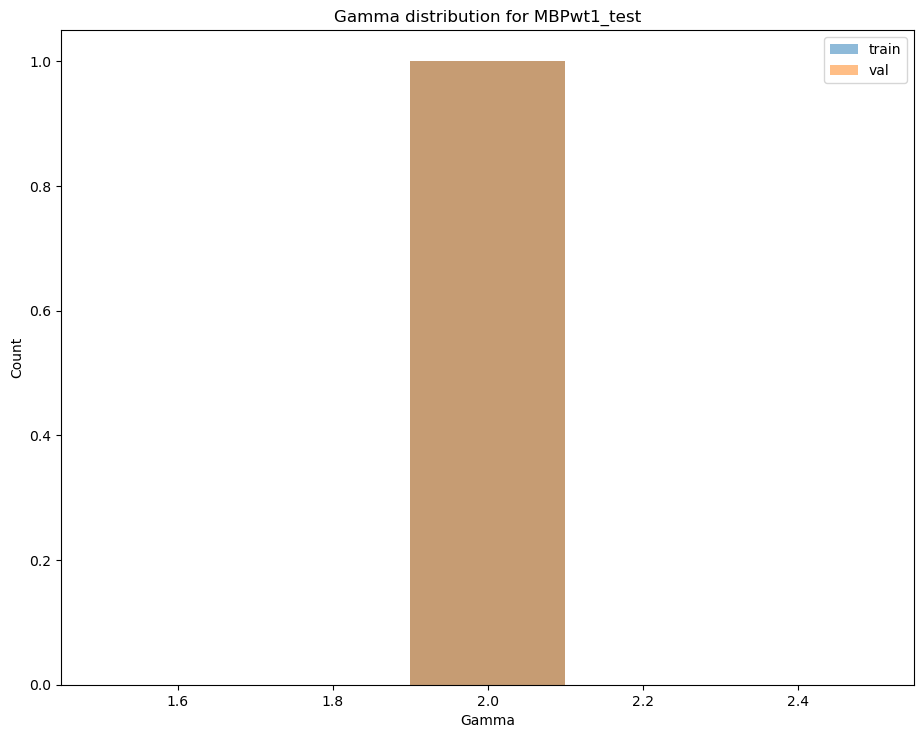

['train_MBPwt1_test_1']
['val_MBPwt1_test_1']
plot_dfracs_compare
           30       240      1800     14400  peptide           calc_name  \
0    0.394110  0.667680  0.902490  1.000000        0        Experimental   
1    0.376200  0.635670  0.869210  1.000000        1        Experimental   
2    0.151360  0.221100  0.462110  1.000000        2        Experimental   
3    0.362850  0.473370  0.693240  1.000000        3        Experimental   
4    0.127020  0.195950  0.460170  1.000000        4        Experimental   
..        ...       ...       ...       ...      ...                 ...   
301  0.728799  0.822750  0.931744  0.998096      106  test_MBPwt1_test_1   
302  0.639299  0.803133  0.948018  0.998952      107  test_MBPwt1_test_1   
303  0.664511  0.805784  0.945283  0.998896      108  test_MBPwt1_test_1   
304  0.577876  0.659498  0.849842  0.995810      109  test_MBPwt1_test_1   
305  0.529909  0.779156  0.967908  0.999998      110  test_MBPwt1_test_1   

     ResStr  ResEnd p

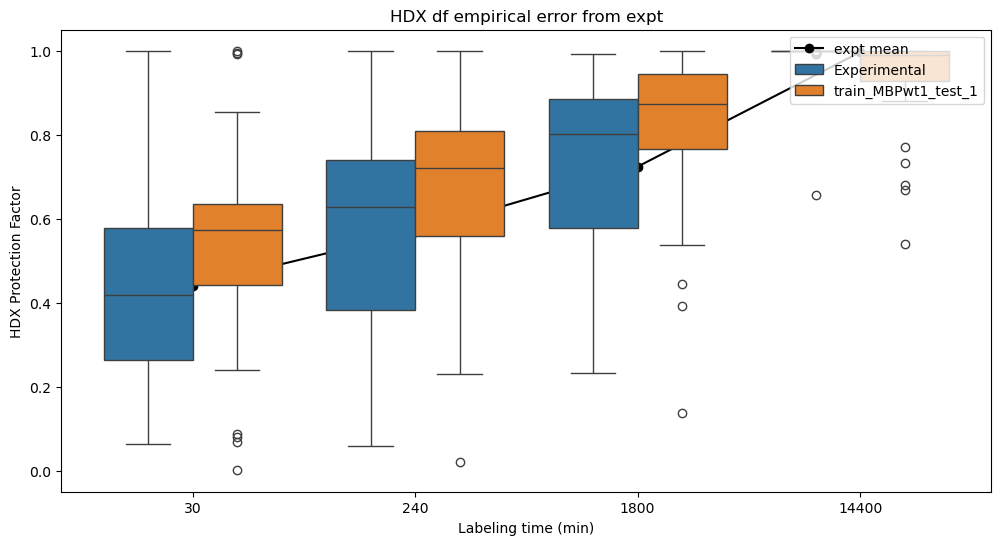

plot_dfracs_compare
           30       240      1800     14400  peptide           calc_name  \
0    0.394110  0.667680  0.902490  1.000000        0        Experimental   
1    0.376200  0.635670  0.869210  1.000000        1        Experimental   
2    0.151360  0.221100  0.462110  1.000000        2        Experimental   
3    0.362850  0.473370  0.693240  1.000000        3        Experimental   
4    0.127020  0.195950  0.460170  1.000000        4        Experimental   
..        ...       ...       ...       ...      ...                 ...   
301  0.728799  0.822750  0.931744  0.998096      106  test_MBPwt1_test_1   
302  0.639299  0.803133  0.948018  0.998952      107  test_MBPwt1_test_1   
303  0.664511  0.805784  0.945283  0.998896      108  test_MBPwt1_test_1   
304  0.577876  0.659498  0.849842  0.995810      109  test_MBPwt1_test_1   
305  0.529909  0.779156  0.967908  0.999998      110  test_MBPwt1_test_1   

     ResStr  ResEnd path  
0       NaN     NaN  NaN  
1       NaN  

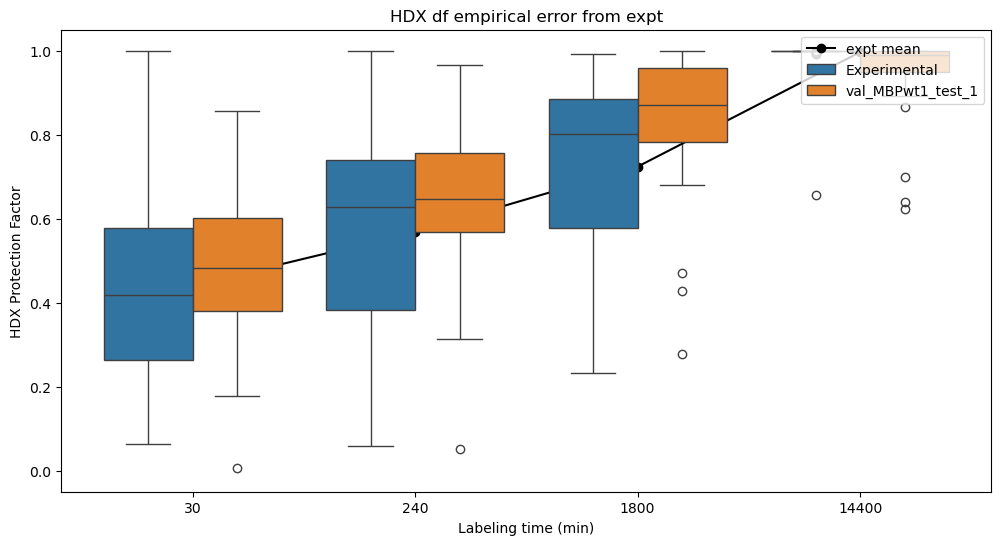

Restoring trainval peptide numbers
train_rep_names ['train_MBPwt1_test_1']
val_rep_names ['val_MBPwt1_test_1']
test_rep_names ['test_MBPwt1_test_1']
train_rep_peptides [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 66, 67, 68, 69, 102, 103, 104, 105, 106, 107, 108, 109, 110]
val_rep_peptides [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88]
test_rep_peptides [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110]
manual merge d

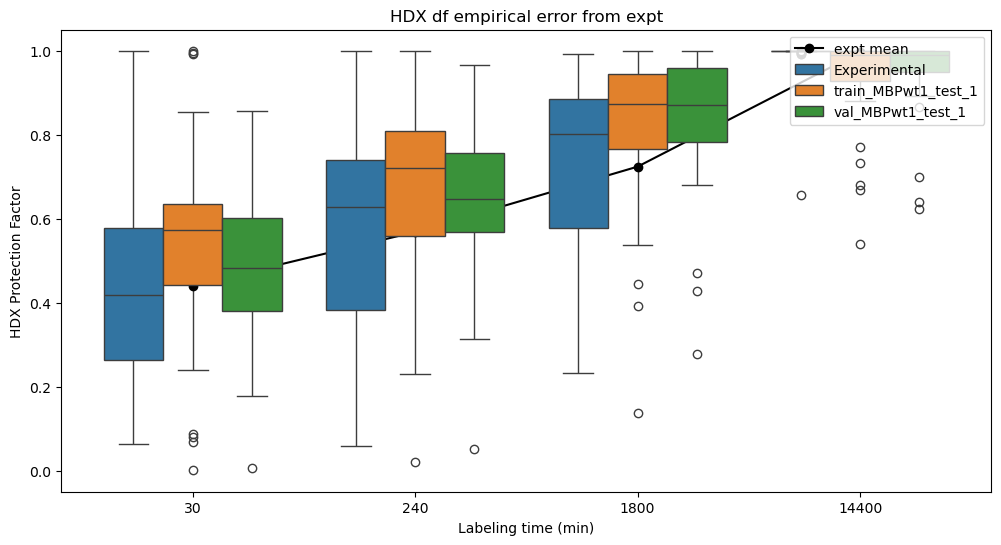

plotting paired errors
           30       240      1800     14400  peptide          calc_name  \
0    0.394110  0.667680  0.902490  1.000000        0       Experimental   
1    0.376200  0.635670  0.869210  1.000000        1       Experimental   
2    0.151360  0.221100  0.462110  1.000000        2       Experimental   
3    0.362850  0.473370  0.693240  1.000000        3       Experimental   
4    0.127020  0.195950  0.460170  1.000000        4       Experimental   
..        ...       ...       ...       ...      ...                ...   
190  0.373648  0.557185  0.769888  0.951617       84  val_MBPwt1_test_1   
191  0.474576  0.588355  0.748742  0.944705       85  val_MBPwt1_test_1   
192  0.408192  0.499954  0.680221  0.929624       86  val_MBPwt1_test_1   
193  0.448846  0.548635  0.738790  0.967772       87  val_MBPwt1_test_1   
194  0.498438  0.607380  0.805311  0.997406       88  val_MBPwt1_test_1   

     ResStr  ResEnd                                               path  
0  

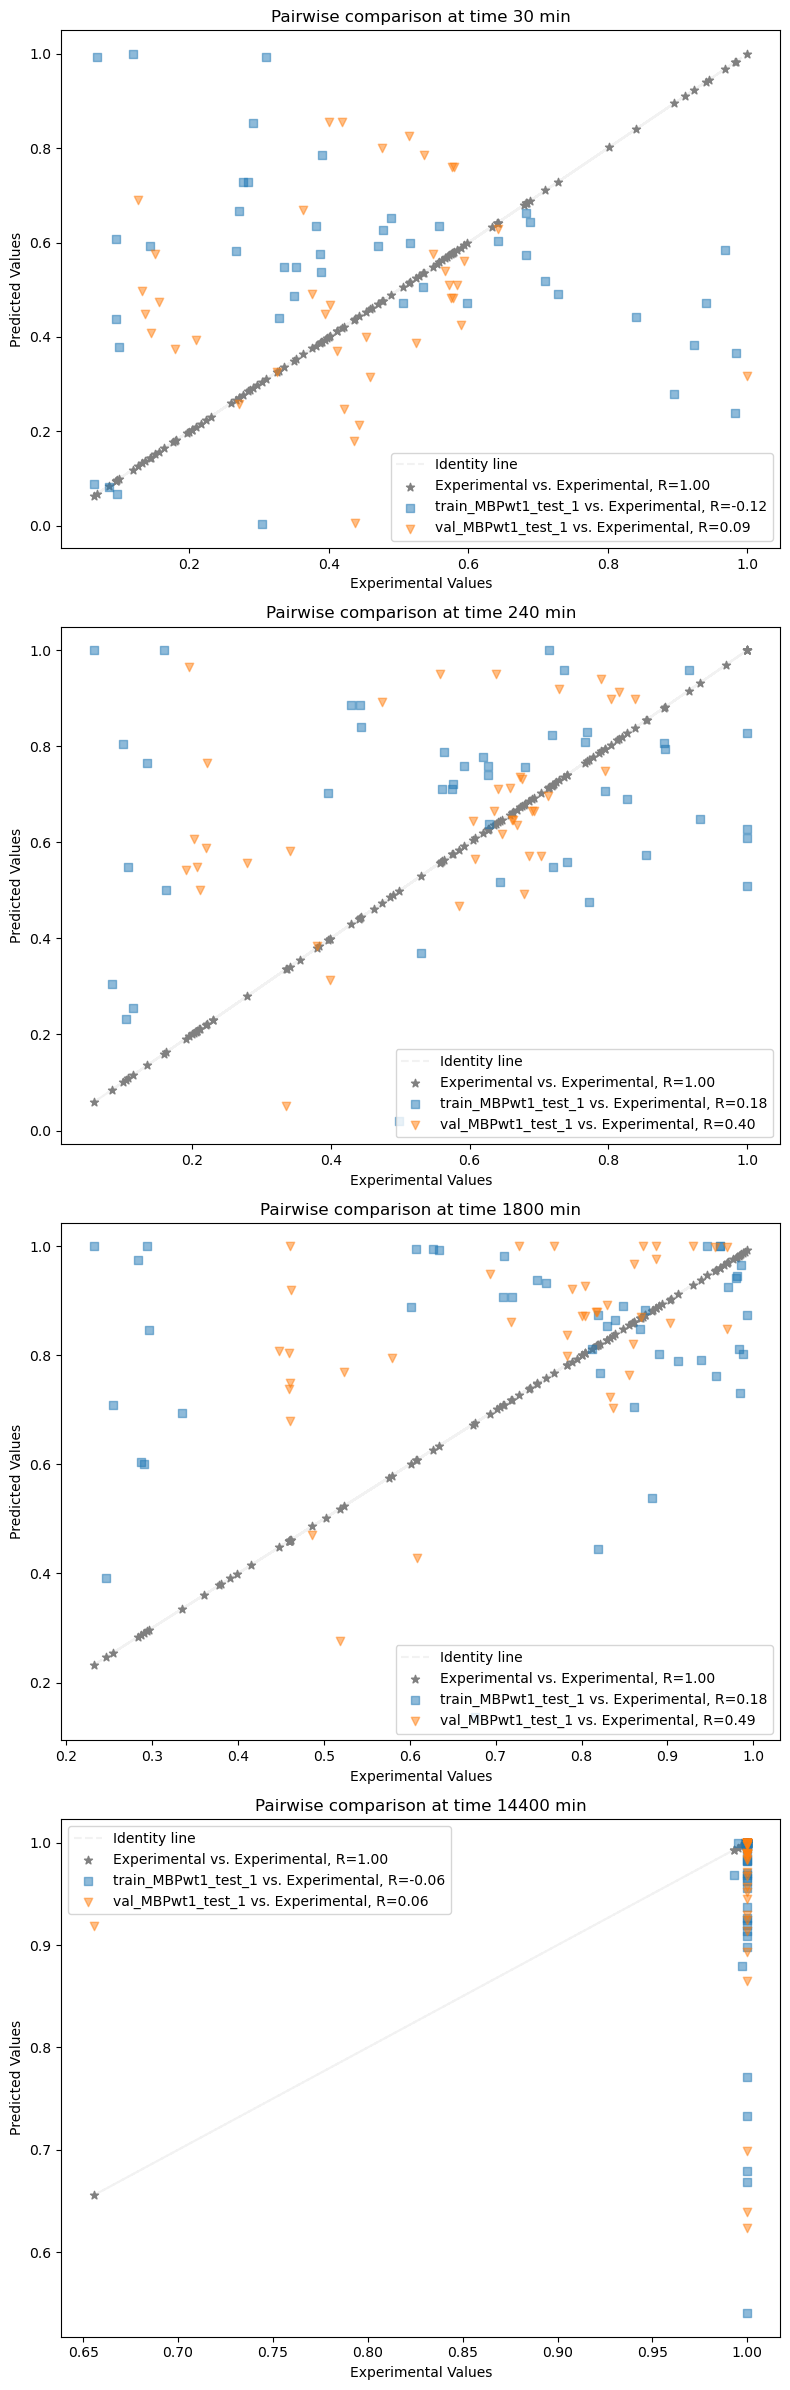

plotting paired trainval agreement
           30       240      1800     14400  peptide          calc_name  \
0    0.394110  0.667680  0.902490  1.000000        0       Experimental   
1    0.376200  0.635670  0.869210  1.000000        1       Experimental   
2    0.151360  0.221100  0.462110  1.000000        2       Experimental   
3    0.362850  0.473370  0.693240  1.000000        3       Experimental   
4    0.127020  0.195950  0.460170  1.000000        4       Experimental   
..        ...       ...       ...       ...      ...                ...   
190  0.373648  0.557185  0.769888  0.951617       84  val_MBPwt1_test_1   
191  0.474576  0.588355  0.748742  0.944705       85  val_MBPwt1_test_1   
192  0.408192  0.499954  0.680221  0.929624       86  val_MBPwt1_test_1   
193  0.448846  0.548635  0.738790  0.967772       87  val_MBPwt1_test_1   
194  0.498438  0.607380  0.805311  0.997406       88  val_MBPwt1_test_1   

     ResStr  ResEnd                                             

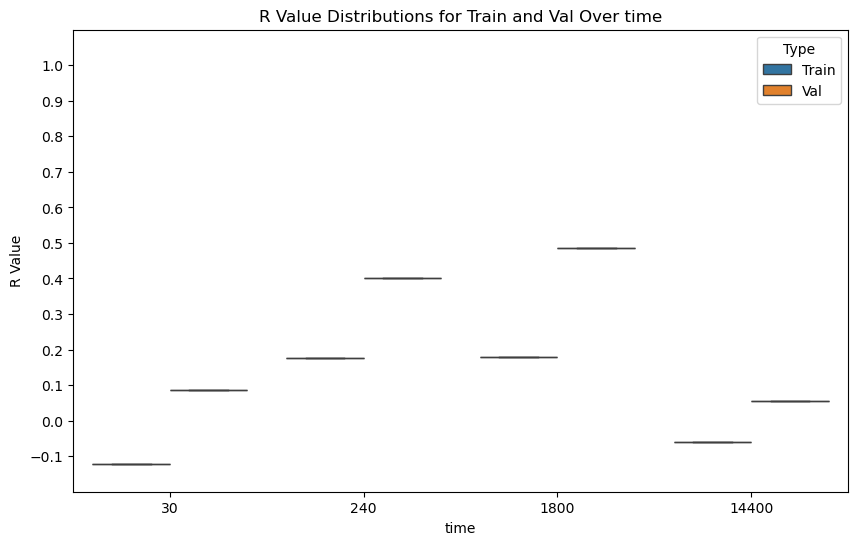

nan_df
           30       240      1800     14400  peptide            calc_name  \
0    0.239540  0.370550  0.445390  0.679430       25  train_MBPwt1_test_1   
1    0.366280  0.475460  0.537830  0.732860       26  train_MBPwt1_test_1   
2    0.378140  0.549190  0.603850  0.771020       27  train_MBPwt1_test_1   
3    0.607410  0.803980  0.846450  0.913470       28  train_MBPwt1_test_1   
4    1.000000  1.000000  1.000000  1.000000       29  train_MBPwt1_test_1   
..        ...       ...       ...       ...      ...                  ...   
163  0.373648  0.557185  0.769888  0.951617       84    val_MBPwt1_test_1   
164  0.474576  0.588355  0.748742  0.944705       85    val_MBPwt1_test_1   
165  0.408192  0.499954  0.680221  0.929624       86    val_MBPwt1_test_1   
166  0.448846  0.548635  0.738790  0.967772       87    val_MBPwt1_test_1   
167  0.498438  0.607380  0.805311  0.997406       88    val_MBPwt1_test_1   

     ResStr  ResEnd                                               pa

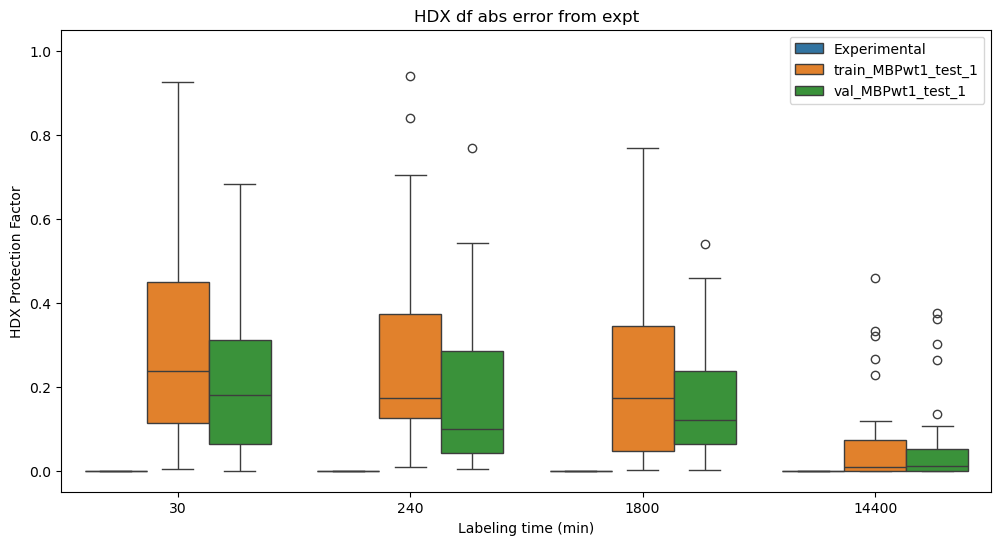

plot_dfracs_compare_MSE
          30      240     1800    14400  peptide            calc_name  ResStr  \
0    0.23954  0.37055  0.44539  0.67943       25  train_MBPwt1_test_1     NaN   
1    0.36628  0.47546  0.53783  0.73286       26  train_MBPwt1_test_1     NaN   
2    0.37814  0.54919  0.60385  0.77102       27  train_MBPwt1_test_1     NaN   
3    0.60741  0.80398  0.84645  0.91347       28  train_MBPwt1_test_1     NaN   
4    1.00000  1.00000  1.00000  1.00000       29  train_MBPwt1_test_1     NaN   
..       ...      ...      ...      ...      ...                  ...     ...   
274  0.38982  0.76948  0.97076  1.00000      106         Experimental     NaN   
275  0.68306  0.87952  0.98129  1.00000      107         Experimental     NaN   
276  0.68912  0.88158  0.97928  1.00000      108         Experimental     NaN   
277  0.59870  0.85358  0.98298  1.00000      109         Experimental     NaN   
278  0.96768  1.00000  0.98548  0.99509      110         Experimental     NaN   

   

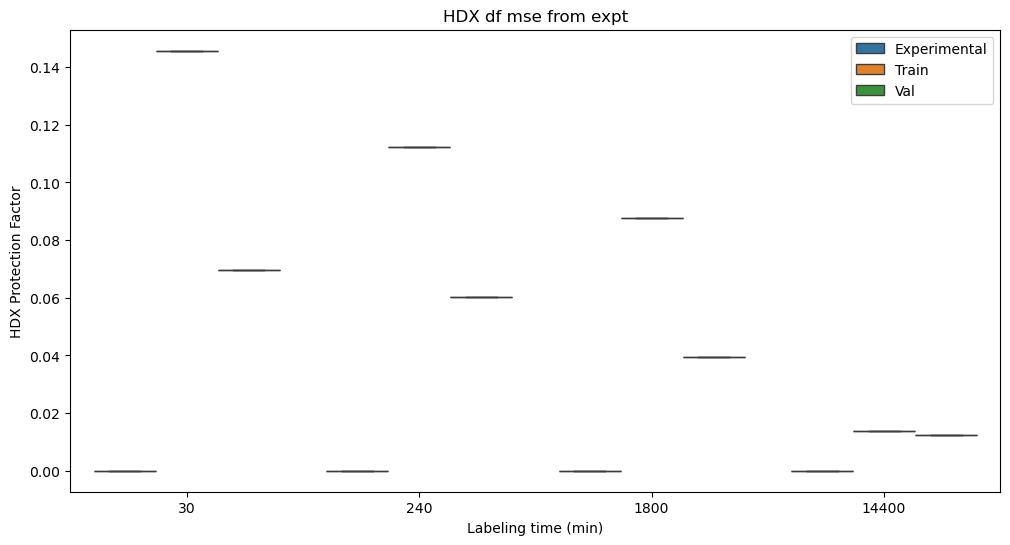

Saving experiment to:  logs/AvsB_S3_1708611704.pkl


/home/alexi/Documents/ValDX/ValDX/Experiment_ABC.py:929: UserWarning: Reader has no dt information, set to 1.0 ps
  pickle.dump(self, f)


Path to 'HDXER_ENV' environment: /home/alexi/anaconda3/envs/HDXER_ENV
Preparing HDX data for Experimental
Path /home/alexi/Documents/ValDX/raw_data/MBP/MaltoseBindingProtein/MBP_1ANF.dat
AVG: ncol = 6, len(names) = 4
                                                 HDX  \
0  /home/alexi/Documents/ValDX/raw_data/MBP/Malto...   
1                                                NaN   

                                                 SEG     calc_name  \
0  /home/alexi/Documents/ValDX/raw_data/MBP/Malto...  Experimental   
1                                                NaN   MBPwt1_test   

  experimental                                                top  \
0        False                                                NaN   
1          NaN  /home/alexi/Documents/ValDX/raw_data/raw_pdbs/...   

                                                traj  
0                                                NaN  
1  [/home/alexi/Documents/ValDX/raw_data/raw_pdbs...  
Structures loaded MBPwt1_test:

/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/alexi/Documents/ValDX/ValDX/Experiment_ABC.py:733: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_segs["calc_name"] = train_rep_name
/home/alexi/Documents/ValDX/ValDX/Experiment_ABC.py:734: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#r

Path to 'HDXER_ENV' environment: /home/alexi/anaconda3/envs/HDXER_ENV
python /home/alexi/Documents/HDXer/HDXer/calc_hdx.py -t /home/alexi/Documents/ValDX/raw_data/raw_pdbs/clean_pdbs/1ANF_chain_A_small.xtc -p /home/alexi/Documents/ValDX/raw_data/raw_pdbs/clean_pdbs/1ANF_chain_A.pdb -m BestVendruscolo -log /home/alexi/Documents/ValDX/data/LvsX_SR/train_MBPwt1_test_1/calc_hdx_train_MBPwt1_test_1.log -out /home/alexi/Documents/ValDX/data/LvsX_SR/train_MBPwt1_test_1/out__train_MBPwt1_test_1 -seg /home/alexi/Documents/ValDX/data/LvsX_SR/train_MBPwt1_test_1/train_residue_segs__MBPwt1_test_.txt -mopt "{ 'save_detailed' : True }" --times 30 240 1800 14400 -str 1
Path to 'HDXER_ENV' environment: /home/alexi/anaconda3/envs/HDXER_ENV
Residue predictions complete


/home/alexi/Documents/HDXer/HDXer/dfpred.py:505: RuntimeWarning: divide by zero encountered in log
  logerr = logf + np.log(err) + np.log(time) # sd(e^Aa) = f * sd(A) * a
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaco

Path /home/alexi/Documents/ValDX/data/LvsX_SR/train_MBPwt1_test_1/out__train_MBPwt1_test_1Segment_average_fractions.dat
AVG: ncol = 6, len(names) = 4
Experimental MBPwt1_test True 1
/home/alexi/Documents/ValDX/data/LvsX_SR/train_MBPwt1_test_1/train_MBPwt1_test_1_expt_dfracs.dat
/home/alexi/Documents/ValDX/data/LvsX_SR/train_MBPwt1_test_1
/home/alexi/Documents/ValDX/data/LvsX_SR/train_MBPwt1_test_1/out__train_MBPwt1_test_1Intrinsic_rates.dat
REWIGHTING train_MBPwt1_test_1 with Exponent: 0
[{'do_reweight': False, 'do_params': True, 'stepfactor': 0.001, 'basegamma': 1, 'predictHDX_dir': ['/home/alexi/Documents/ValDX/data/LvsX_SR/train_MBPwt1_test_1'], 'kint_file': '/home/alexi/Documents/ValDX/data/LvsX_SR/train_MBPwt1_test_1/out__train_MBPwt1_test_1Intrinsic_rates.dat', 'exp_file': '/home/alexi/Documents/ValDX/data/LvsX_SR/train_MBPwt1_test_1/train_MBPwt1_test_1_expt_dfracs.dat', 'times': [30, 240, 1800, 14400], 'restart_interval': 100, 'out_prefix': '/home/alexi/Documents/ValDX/data/LvsX

/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/MDAnalysis/core/universe.py:817: DeprecationWarning: The bfactor topology attribute is only provided as an alias to the tempfactor attribute. It will be removed in 3.0. Please use the tempfactor attribute instead.
  warnings.warn(BFACTOR_WARNING, DeprecationWarning)
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/MDAnalysis/core/topologyattrs.py:282: DeprecationWarning: The bfactor topology attribute is only provided as an alias to the tempfactor attribute. It will be removed in 3.0. Please use the tempfactor attribute instead.
  warnings.warn(BFACTOR_WARNING, DeprecationWarning)
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/MDAnalysis/coordinates/PDB.py:1129: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"


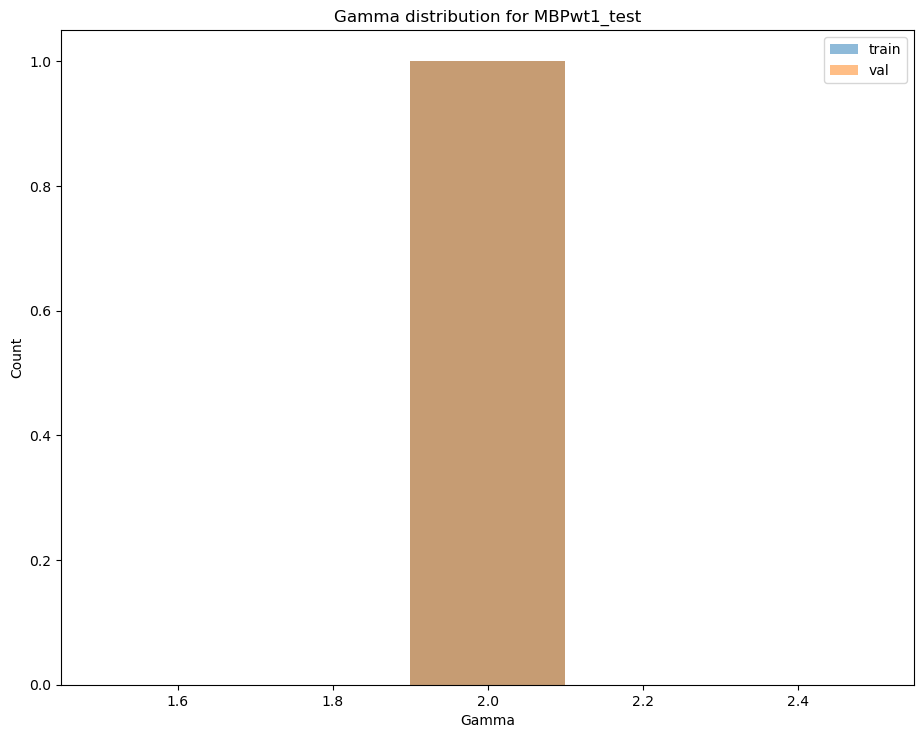

['train_MBPwt1_test_1']
['val_MBPwt1_test_1']
plot_dfracs_compare
           30       240      1800     14400  peptide           calc_name  \
0    0.394110  0.667680  0.902490  1.000000        0        Experimental   
1    0.376200  0.635670  0.869210  1.000000        1        Experimental   
2    0.151360  0.221100  0.462110  1.000000        2        Experimental   
3    0.362850  0.473370  0.693240  1.000000        3        Experimental   
4    0.127020  0.195950  0.460170  1.000000        4        Experimental   
..        ...       ...       ...       ...      ...                 ...   
258  0.670261  0.773599  0.873872  0.973441      106  test_MBPwt1_test_1   
259  0.538500  0.741195  0.875118  0.983724      107  test_MBPwt1_test_1   
260  0.563543  0.758930  0.869627  0.982867      108  test_MBPwt1_test_1   
261  0.520767  0.621072  0.726631  0.941571      109  test_MBPwt1_test_1   
262  0.377458  0.701589  0.876641  0.996292      110  test_MBPwt1_test_1   

     ResStr  ResEnd p

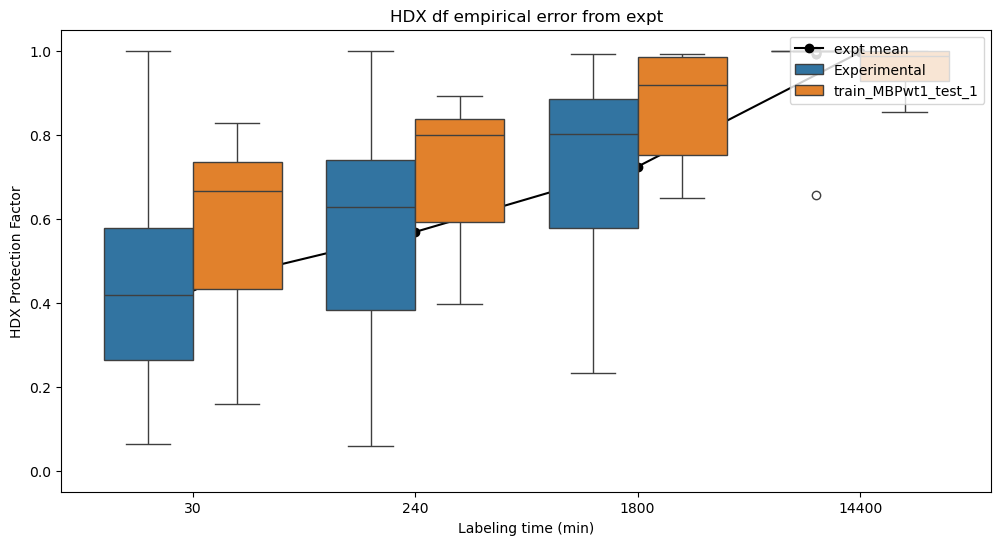

plot_dfracs_compare
           30       240      1800     14400  peptide           calc_name  \
0    0.394110  0.667680  0.902490  1.000000        0        Experimental   
1    0.376200  0.635670  0.869210  1.000000        1        Experimental   
2    0.151360  0.221100  0.462110  1.000000        2        Experimental   
3    0.362850  0.473370  0.693240  1.000000        3        Experimental   
4    0.127020  0.195950  0.460170  1.000000        4        Experimental   
..        ...       ...       ...       ...      ...                 ...   
258  0.670261  0.773599  0.873872  0.973441      106  test_MBPwt1_test_1   
259  0.538500  0.741195  0.875118  0.983724      107  test_MBPwt1_test_1   
260  0.563543  0.758930  0.869627  0.982867      108  test_MBPwt1_test_1   
261  0.520767  0.621072  0.726631  0.941571      109  test_MBPwt1_test_1   
262  0.377458  0.701589  0.876641  0.996292      110  test_MBPwt1_test_1   

     ResStr  ResEnd path  
0       NaN     NaN  NaN  
1       NaN  

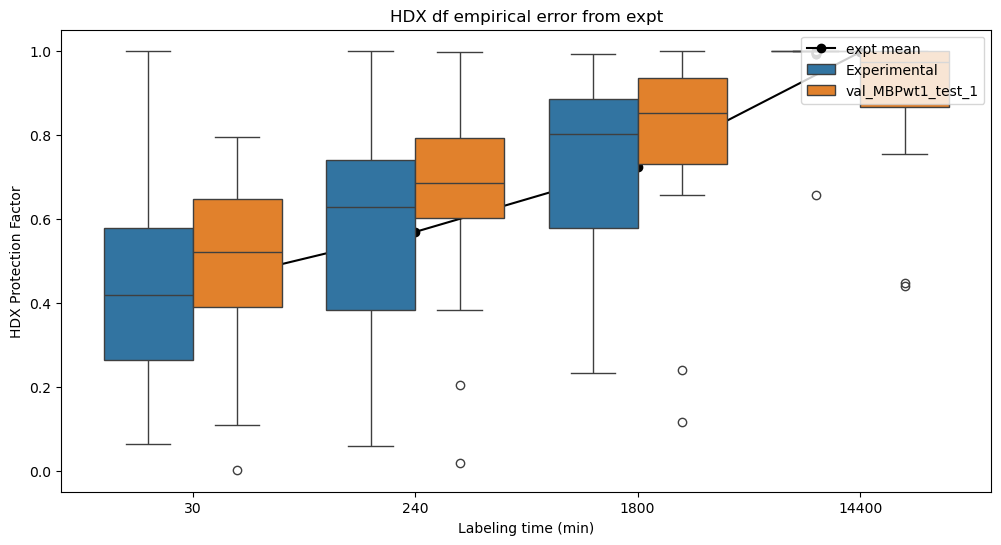

Restoring trainval peptide numbers
train_rep_names ['train_MBPwt1_test_1']
val_rep_names ['val_MBPwt1_test_1']
test_rep_names ['test_MBPwt1_test_1']
train_rep_peptides [0, 1, 2, 5, 7, 8, 9, 10, 11, 12, 13, 75, 76, 77]
val_rep_peptides [28, 29, 30, 31, 32, 33, 34, 35, 42, 46, 47, 48, 49, 50, 51, 58, 63, 72, 79, 81, 82, 89, 103, 104, 105, 106, 109]
test_rep_peptides [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110]
manual merge df
          30       240      1800     14400  peptide            calc_name  \
0   0.419660  0.583150  0.745790  0.944180        0  train_MBPwt1_test_1   
1   0.467960  0.617

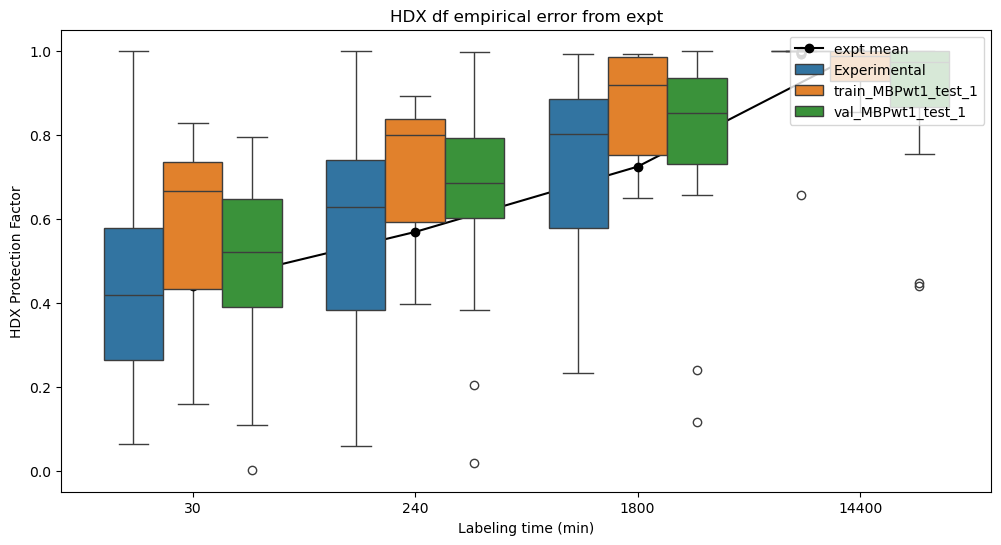

plotting paired errors
           30       240      1800     14400  peptide          calc_name  \
0    0.394110  0.667680  0.902490  1.000000        0       Experimental   
1    0.376200  0.635670  0.869210  1.000000        1       Experimental   
2    0.151360  0.221100  0.462110  1.000000        2       Experimental   
3    0.362850  0.473370  0.693240  1.000000        3       Experimental   
4    0.127020  0.195950  0.460170  1.000000        4       Experimental   
..        ...       ...       ...       ...      ...                ...   
147  0.517296  0.652387  0.805868  0.943548      103  val_MBPwt1_test_1   
148  0.681467  0.773430  0.864359  0.920795      104  val_MBPwt1_test_1   
149  0.794840  0.900705  0.996573  1.000000      105  val_MBPwt1_test_1   
150  0.670261  0.773599  0.873872  0.973441      106  val_MBPwt1_test_1   
151  0.520767  0.621072  0.726631  0.941571      109  val_MBPwt1_test_1   

     ResStr  ResEnd                                               path  
0  

/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


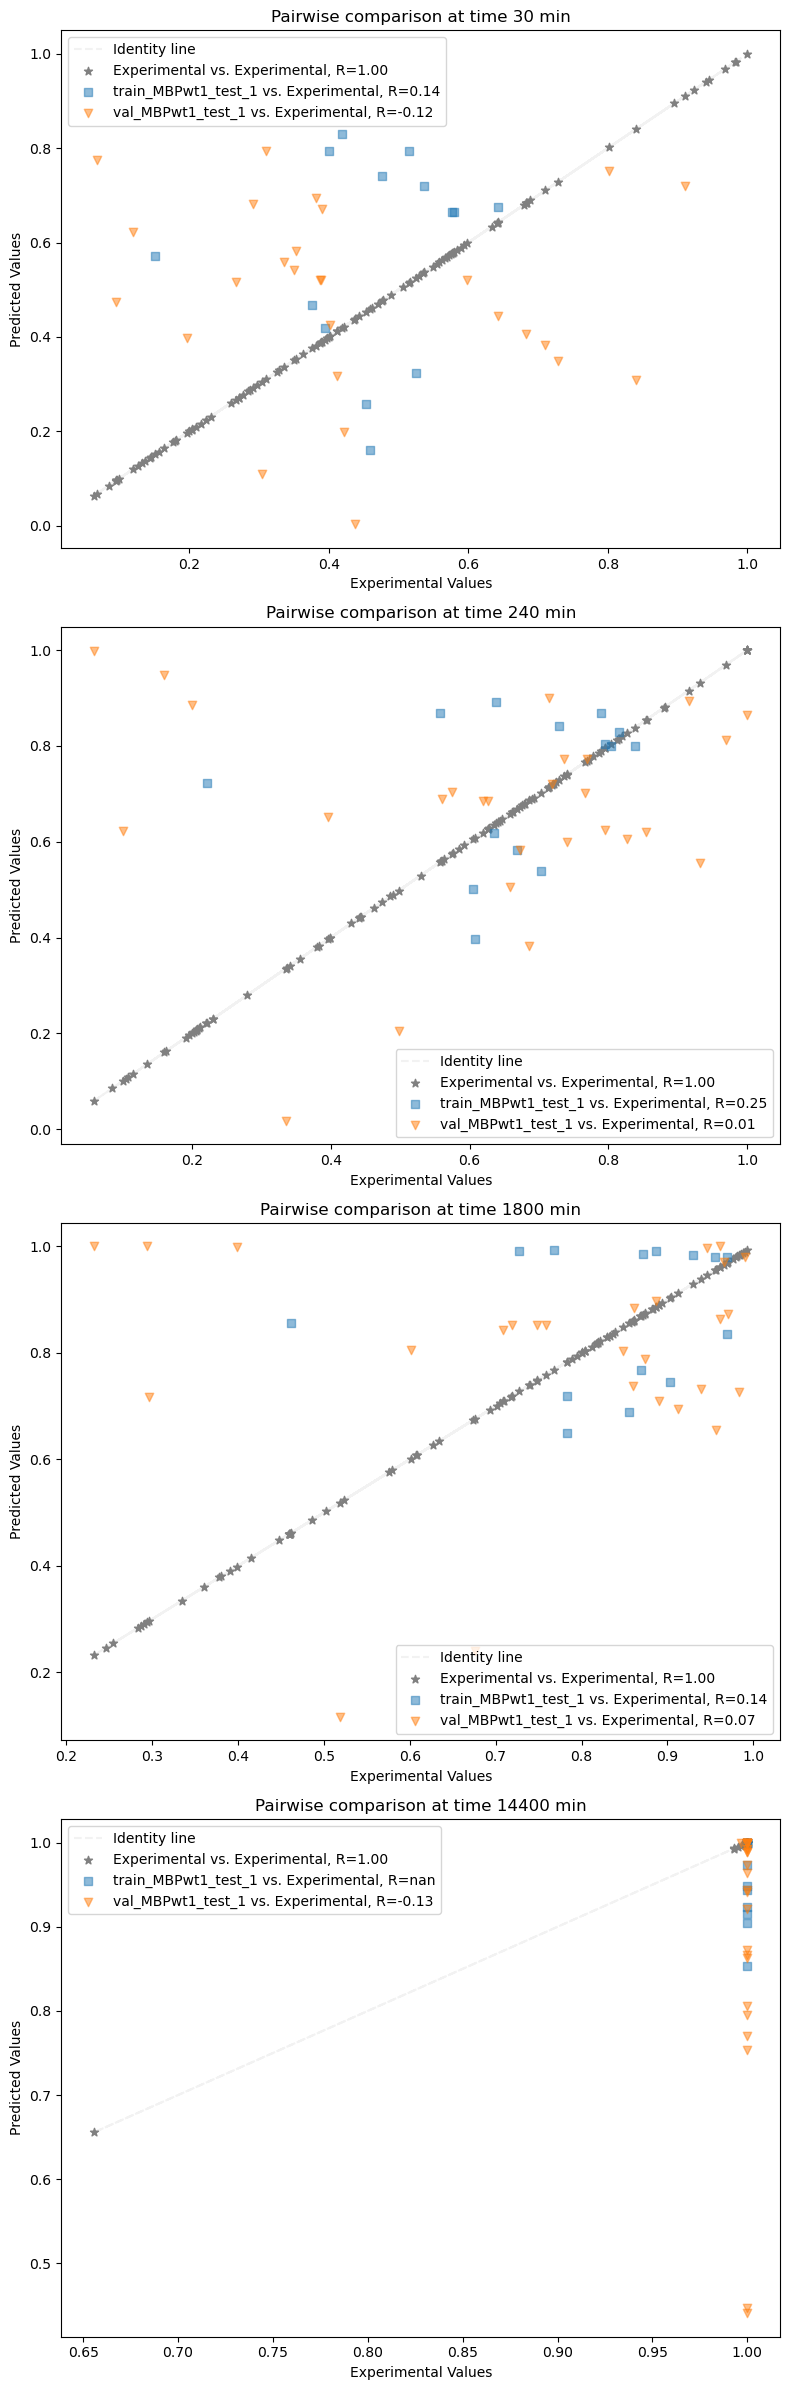

plotting paired trainval agreement
           30       240      1800     14400  peptide          calc_name  \
0    0.394110  0.667680  0.902490  1.000000        0       Experimental   
1    0.376200  0.635670  0.869210  1.000000        1       Experimental   
2    0.151360  0.221100  0.462110  1.000000        2       Experimental   
3    0.362850  0.473370  0.693240  1.000000        3       Experimental   
4    0.127020  0.195950  0.460170  1.000000        4       Experimental   
..        ...       ...       ...       ...      ...                ...   
147  0.517296  0.652387  0.805868  0.943548      103  val_MBPwt1_test_1   
148  0.681467  0.773430  0.864359  0.920795      104  val_MBPwt1_test_1   
149  0.794840  0.900705  0.996573  1.000000      105  val_MBPwt1_test_1   
150  0.670261  0.773599  0.873872  0.973441      106  val_MBPwt1_test_1   
151  0.520767  0.621072  0.726631  0.941571      109  val_MBPwt1_test_1   

     ResStr  ResEnd                                             

/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


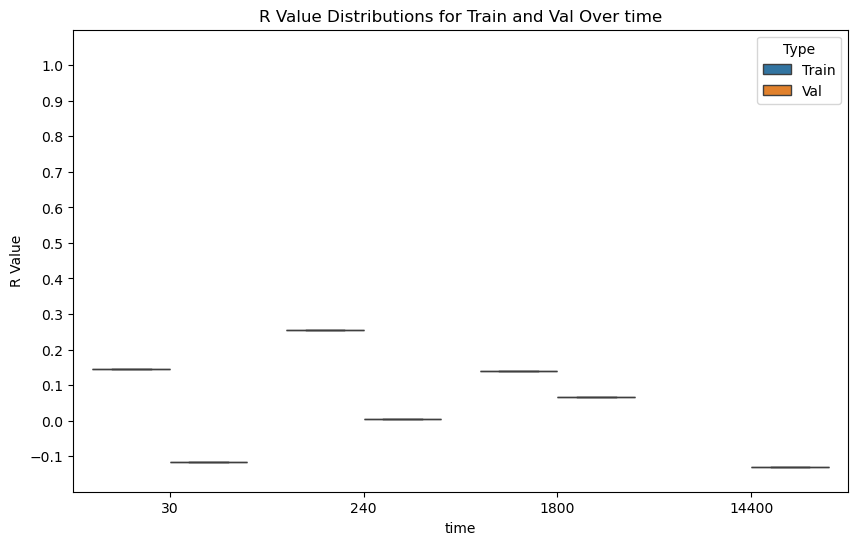

nan_df
          30       240      1800     14400  peptide            calc_name  \
0   0.419660  0.583150  0.745790  0.944180        0  train_MBPwt1_test_1   
1   0.467960  0.617890  0.766980  0.948830        1  train_MBPwt1_test_1   
2   0.570370  0.722530  0.856320  0.972920        2  train_MBPwt1_test_1   
3   0.675460  0.803790  0.835970  0.853330        5  train_MBPwt1_test_1   
4   0.665370  0.799250  0.979190  1.000000        7  train_MBPwt1_test_1   
..       ...       ...       ...       ...      ...                  ...   
77  0.517296  0.652387  0.805868  0.943548      103    val_MBPwt1_test_1   
78  0.681467  0.773430  0.864359  0.920795      104    val_MBPwt1_test_1   
79  0.794840  0.900705  0.996573  1.000000      105    val_MBPwt1_test_1   
80  0.670261  0.773599  0.873872  0.973441      106    val_MBPwt1_test_1   
81  0.520767  0.621072  0.726631  0.941571      109    val_MBPwt1_test_1   

    ResStr  ResEnd                                               path  
0      N

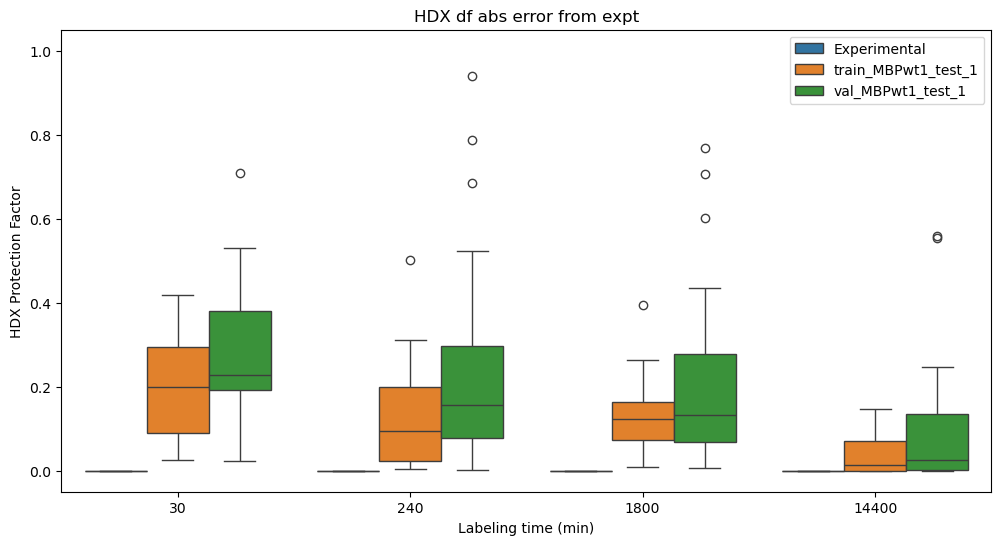

plot_dfracs_compare_MSE
          30      240     1800    14400  peptide            calc_name  ResStr  \
0    0.41966  0.58315  0.74579  0.94418        0  train_MBPwt1_test_1     NaN   
1    0.46796  0.61789  0.76698  0.94883        1  train_MBPwt1_test_1     NaN   
2    0.57037  0.72253  0.85632  0.97292        2  train_MBPwt1_test_1     NaN   
3    0.67546  0.80379  0.83597  0.85333        5  train_MBPwt1_test_1     NaN   
4    0.66537  0.79925  0.97919  1.00000        7  train_MBPwt1_test_1     NaN   
..       ...      ...      ...      ...      ...                  ...     ...   
188  0.38982  0.76948  0.97076  1.00000      106         Experimental     NaN   
189  0.68306  0.87952  0.98129  1.00000      107         Experimental     NaN   
190  0.68912  0.88158  0.97928  1.00000      108         Experimental     NaN   
191  0.59870  0.85358  0.98298  1.00000      109         Experimental     NaN   
192  0.96768  1.00000  0.98548  0.99509      110         Experimental     NaN   

   

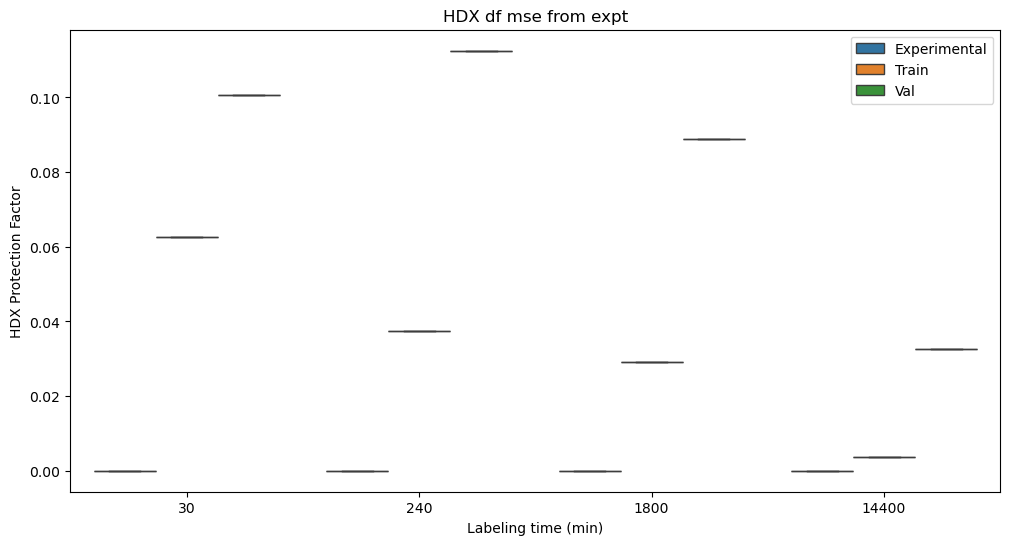

Saving experiment to:  logs/LvsX_SR_1708611727.pkl


/home/alexi/Documents/ValDX/ValDX/Experiment_ABC.py:929: UserWarning: Reader has no dt information, set to 1.0 ps
  pickle.dump(self, f)


Path to 'HDXER_ENV' environment: /home/alexi/anaconda3/envs/HDXER_ENV
Preparing HDX data for Experimental
Path /home/alexi/Documents/ValDX/raw_data/MBP/MaltoseBindingProtein/MBP_1ANF.dat
AVG: ncol = 6, len(names) = 4
                                                 HDX  \
0  /home/alexi/Documents/ValDX/raw_data/MBP/Malto...   
1                                                NaN   

                                                 SEG     calc_name  \
0  /home/alexi/Documents/ValDX/raw_data/MBP/Malto...  Experimental   
1                                                NaN   MBPwt1_test   

  experimental                                                top  \
0        False                                                NaN   
1          NaN  /home/alexi/Documents/ValDX/raw_data/raw_pdbs/...   

                                                traj  
0                                                NaN  
1  [/home/alexi/Documents/ValDX/raw_data/raw_pdbs...  
Structures loaded MBPwt1_test:

/home/alexi/Documents/ValDX/ValDX/Experiment_ABC.py:733: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_segs["calc_name"] = train_rep_name
/home/alexi/Documents/ValDX/ValDX/Experiment_ABC.py:734: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_segs["calc_name"] = val_rep_name
/home/alexi/Documents/ValDX/ValDX/Experiment_ABC.py:748: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

Path to 'HDXER_ENV' environment: /home/alexi/anaconda3/envs/HDXER_ENV
python /home/alexi/Documents/HDXer/HDXer/calc_hdx.py -t /home/alexi/Documents/ValDX/raw_data/raw_pdbs/clean_pdbs/1ANF_chain_A_small.xtc -p /home/alexi/Documents/ValDX/raw_data/raw_pdbs/clean_pdbs/1ANF_chain_A.pdb -m BestVendruscolo -log /home/alexi/Documents/ValDX/data/mixAandB_Sp/train_MBPwt1_test_1/calc_hdx_train_MBPwt1_test_1.log -out /home/alexi/Documents/ValDX/data/mixAandB_Sp/train_MBPwt1_test_1/out__train_MBPwt1_test_1 -seg /home/alexi/Documents/ValDX/data/mixAandB_Sp/train_MBPwt1_test_1/train_residue_segs__MBPwt1_test_.txt -mopt "{ 'save_detailed' : True }" --times 30 240 1800 14400 -str 1
Path to 'HDXER_ENV' environment: /home/alexi/anaconda3/envs/HDXER_ENV
Residue predictions complete


/home/alexi/Documents/HDXer/HDXer/dfpred.py:505: RuntimeWarning: divide by zero encountered in log
  logerr = logf + np.log(err) + np.log(time) # sd(e^Aa) = f * sd(A) * a
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexi/anaco

Path /home/alexi/Documents/ValDX/data/mixAandB_Sp/train_MBPwt1_test_1/out__train_MBPwt1_test_1Segment_average_fractions.dat
AVG: ncol = 6, len(names) = 4
Experimental MBPwt1_test True 1
/home/alexi/Documents/ValDX/data/mixAandB_Sp/train_MBPwt1_test_1/train_MBPwt1_test_1_expt_dfracs.dat
/home/alexi/Documents/ValDX/data/mixAandB_Sp/train_MBPwt1_test_1
/home/alexi/Documents/ValDX/data/mixAandB_Sp/train_MBPwt1_test_1/out__train_MBPwt1_test_1Intrinsic_rates.dat
REWIGHTING train_MBPwt1_test_1 with Exponent: 0
[{'do_reweight': False, 'do_params': True, 'stepfactor': 0.001, 'basegamma': 1, 'predictHDX_dir': ['/home/alexi/Documents/ValDX/data/mixAandB_Sp/train_MBPwt1_test_1'], 'kint_file': '/home/alexi/Documents/ValDX/data/mixAandB_Sp/train_MBPwt1_test_1/out__train_MBPwt1_test_1Intrinsic_rates.dat', 'exp_file': '/home/alexi/Documents/ValDX/data/mixAandB_Sp/train_MBPwt1_test_1/train_MBPwt1_test_1_expt_dfracs.dat', 'times': [30, 240, 1800, 14400], 'restart_interval': 100, 'out_prefix': '/home/ale

/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/MDAnalysis/core/universe.py:817: DeprecationWarning: The bfactor topology attribute is only provided as an alias to the tempfactor attribute. It will be removed in 3.0. Please use the tempfactor attribute instead.
  warnings.warn(BFACTOR_WARNING, DeprecationWarning)
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/MDAnalysis/core/topologyattrs.py:282: DeprecationWarning: The bfactor topology attribute is only provided as an alias to the tempfactor attribute. It will be removed in 3.0. Please use the tempfactor attribute instead.
  warnings.warn(BFACTOR_WARNING, DeprecationWarning)
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/MDAnalysis/coordinates/PDB.py:1129: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"


Writing val PDB to results/mixAandB_Sp/val_1_mixAandB_Sp_20240222-142239.pdb


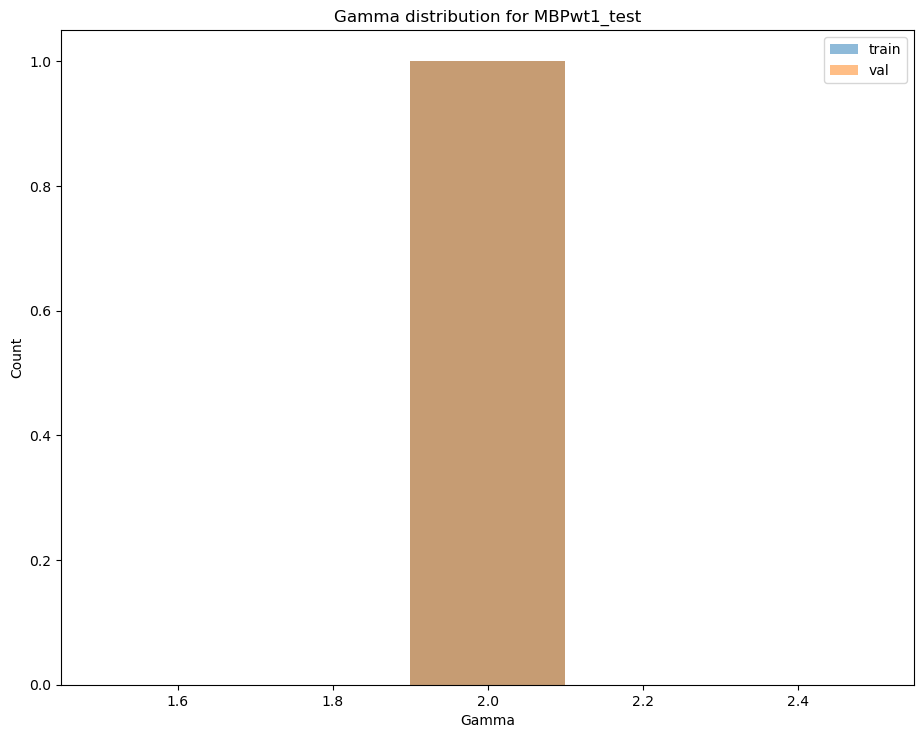

['train_MBPwt1_test_1']
['val_MBPwt1_test_1']
plot_dfracs_compare
           30       240      1800     14400  peptide           calc_name  \
0    0.394110  0.667680  0.902490  1.000000        0        Experimental   
1    0.376200  0.635670  0.869210  1.000000        1        Experimental   
2    0.151360  0.221100  0.462110  1.000000        2        Experimental   
3    0.362850  0.473370  0.693240  1.000000        3        Experimental   
4    0.127020  0.195950  0.460170  1.000000        4        Experimental   
..        ...       ...       ...       ...      ...                 ...   
289  0.593722  0.746605  0.826045  0.930828      106  test_MBPwt1_test_1   
290  0.450704  0.693156  0.806650  0.946228      107  test_MBPwt1_test_1   
291  0.473011  0.719329  0.806735  0.943398      108  test_MBPwt1_test_1   
292  0.476132  0.603705  0.656292  0.847823      109  test_MBPwt1_test_1   
293  0.275904  0.627830  0.782946  0.965051      110  test_MBPwt1_test_1   

     ResStr  ResEnd p

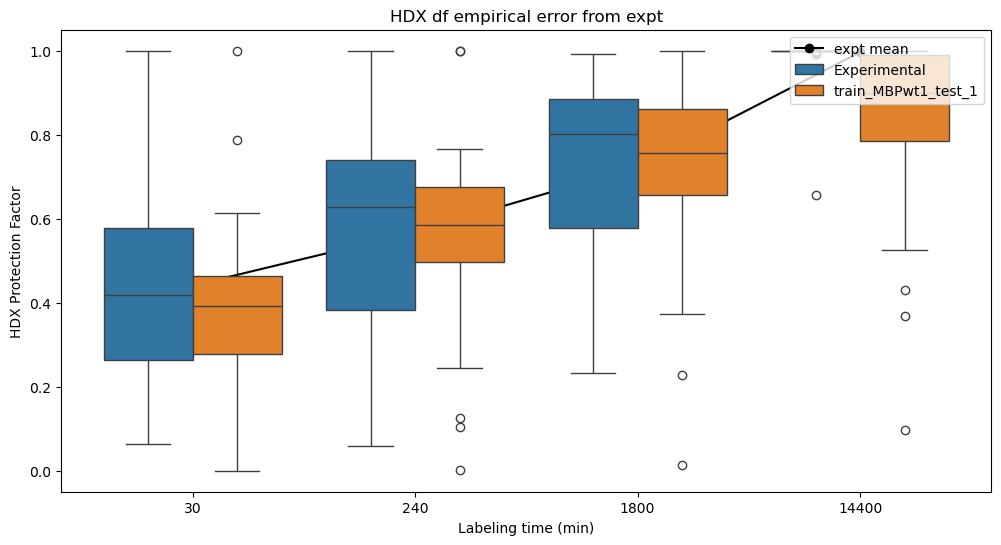

plot_dfracs_compare
           30       240      1800     14400  peptide           calc_name  \
0    0.394110  0.667680  0.902490  1.000000        0        Experimental   
1    0.376200  0.635670  0.869210  1.000000        1        Experimental   
2    0.151360  0.221100  0.462110  1.000000        2        Experimental   
3    0.362850  0.473370  0.693240  1.000000        3        Experimental   
4    0.127020  0.195950  0.460170  1.000000        4        Experimental   
..        ...       ...       ...       ...      ...                 ...   
289  0.593722  0.746605  0.826045  0.930828      106  test_MBPwt1_test_1   
290  0.450704  0.693156  0.806650  0.946228      107  test_MBPwt1_test_1   
291  0.473011  0.719329  0.806735  0.943398      108  test_MBPwt1_test_1   
292  0.476132  0.603705  0.656292  0.847823      109  test_MBPwt1_test_1   
293  0.275904  0.627830  0.782946  0.965051      110  test_MBPwt1_test_1   

     ResStr  ResEnd path  
0       NaN     NaN  NaN  
1       NaN  

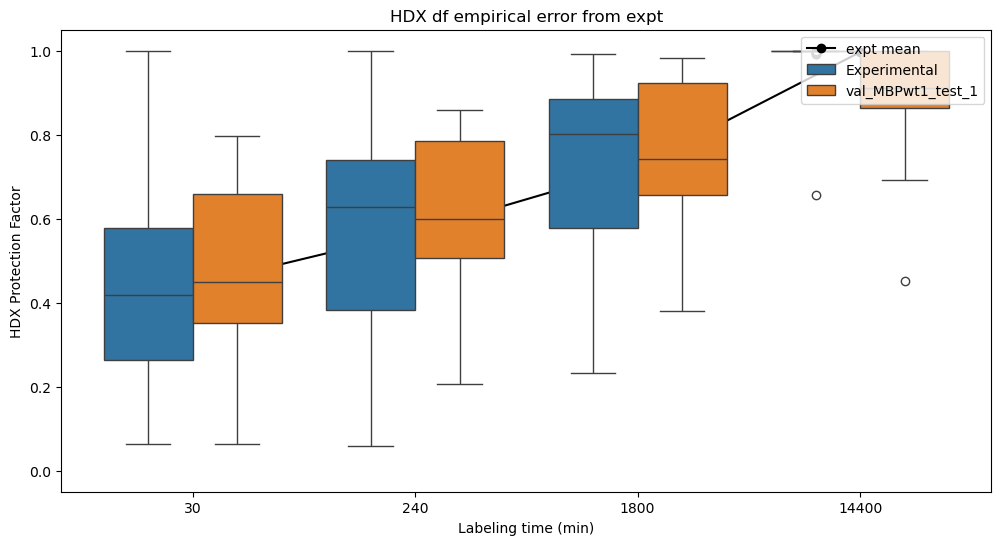

Restoring trainval peptide numbers
train_rep_names ['train_MBPwt1_test_1']
val_rep_names ['val_MBPwt1_test_1']
test_rep_names ['test_MBPwt1_test_1']
train_rep_peptides [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 79, 81, 82, 89, 90, 91, 92]
val_rep_peptides [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 42, 43, 74, 75, 76, 77, 110]
test_rep_peptides [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110]
manual merge df
          30       240      1800     14400  peptide 

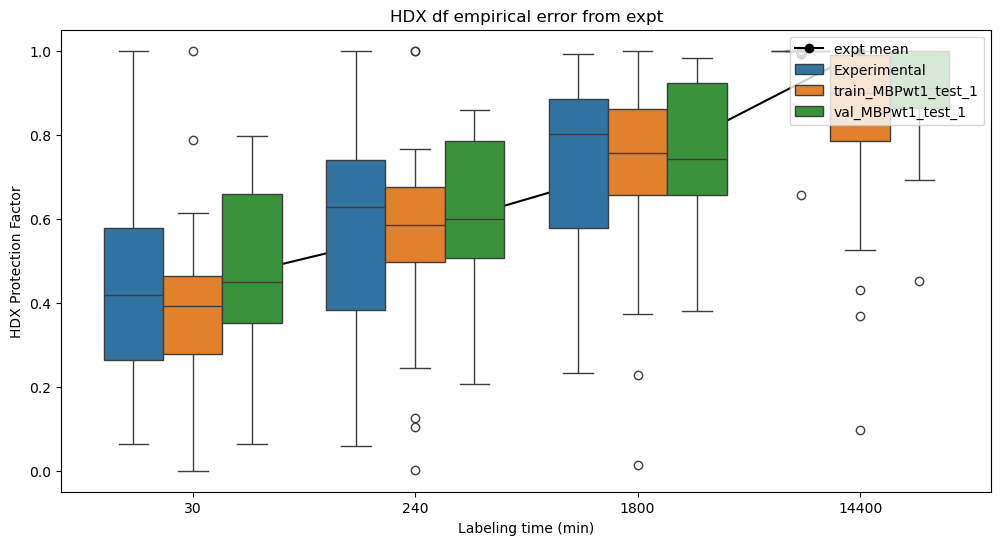

plotting paired errors
           30       240      1800     14400  peptide          calc_name  \
0    0.394110  0.667680  0.902490  1.000000        0       Experimental   
1    0.376200  0.635670  0.869210  1.000000        1       Experimental   
2    0.151360  0.221100  0.462110  1.000000        2       Experimental   
3    0.362850  0.473370  0.693240  1.000000        3       Experimental   
4    0.127020  0.195950  0.460170  1.000000        4       Experimental   
..        ...       ...       ...       ...      ...                ...   
178  0.198222  0.349002  0.379211  0.450730       74  val_MBPwt1_test_1   
179  0.163443  0.359397  0.578400  0.799069       75  val_MBPwt1_test_1   
180  0.231903  0.446735  0.656979  0.836744       76  val_MBPwt1_test_1   
181  0.215547  0.424685  0.576615  0.763220       77  val_MBPwt1_test_1   
182  0.275904  0.627830  0.782946  0.965051      110  val_MBPwt1_test_1   

     ResStr  ResEnd                                               path  
0  

/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


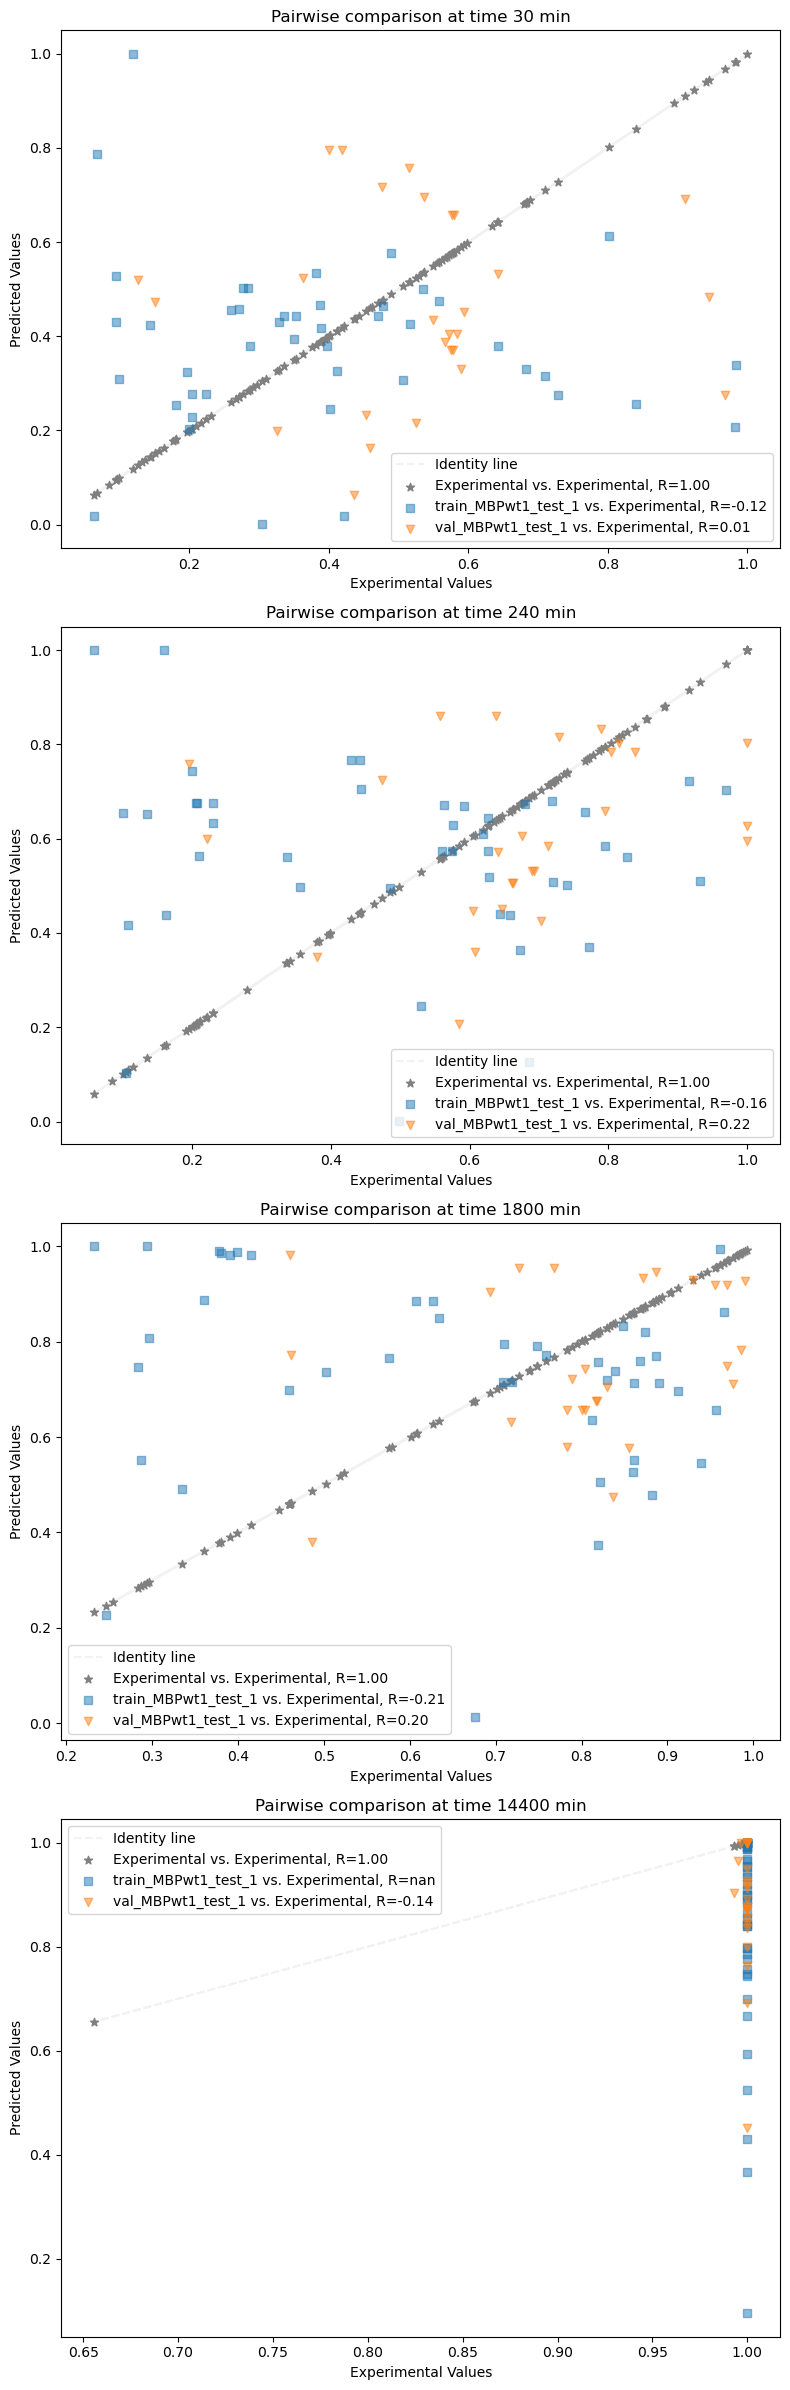

plotting paired trainval agreement
           30       240      1800     14400  peptide          calc_name  \
0    0.394110  0.667680  0.902490  1.000000        0       Experimental   
1    0.376200  0.635670  0.869210  1.000000        1       Experimental   
2    0.151360  0.221100  0.462110  1.000000        2       Experimental   
3    0.362850  0.473370  0.693240  1.000000        3       Experimental   
4    0.127020  0.195950  0.460170  1.000000        4       Experimental   
..        ...       ...       ...       ...      ...                ...   
178  0.198222  0.349002  0.379211  0.450730       74  val_MBPwt1_test_1   
179  0.163443  0.359397  0.578400  0.799069       75  val_MBPwt1_test_1   
180  0.231903  0.446735  0.656979  0.836744       76  val_MBPwt1_test_1   
181  0.215547  0.424685  0.576615  0.763220       77  val_MBPwt1_test_1   
182  0.275904  0.627830  0.782946  0.965051      110  val_MBPwt1_test_1   

     ResStr  ResEnd                                             

/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


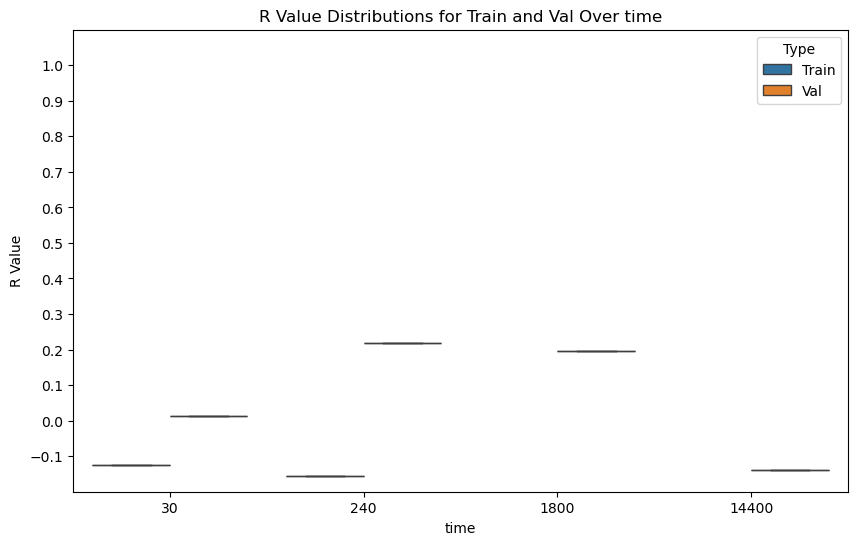

nan_df
           30       240      1800     14400  peptide            calc_name  \
0    0.206240  0.244940  0.373500  0.430610       25  train_MBPwt1_test_1   
1    0.338540  0.370780  0.477920  0.525500       26  train_MBPwt1_test_1   
2    0.310040  0.417560  0.552490  0.593290       27  train_MBPwt1_test_1   
3    0.528340  0.653490  0.808790  0.839790       28  train_MBPwt1_test_1   
4    1.000000  1.000000  1.000000  1.000000       29  train_MBPwt1_test_1   
..        ...       ...       ...       ...      ...                  ...   
139  0.198222  0.349002  0.379211  0.450730       74    val_MBPwt1_test_1   
140  0.163443  0.359397  0.578400  0.799069       75    val_MBPwt1_test_1   
141  0.231903  0.446735  0.656979  0.836744       76    val_MBPwt1_test_1   
142  0.215547  0.424685  0.576615  0.763220       77    val_MBPwt1_test_1   
143  0.275904  0.627830  0.782946  0.965051      110    val_MBPwt1_test_1   

     ResStr  ResEnd                                               pa

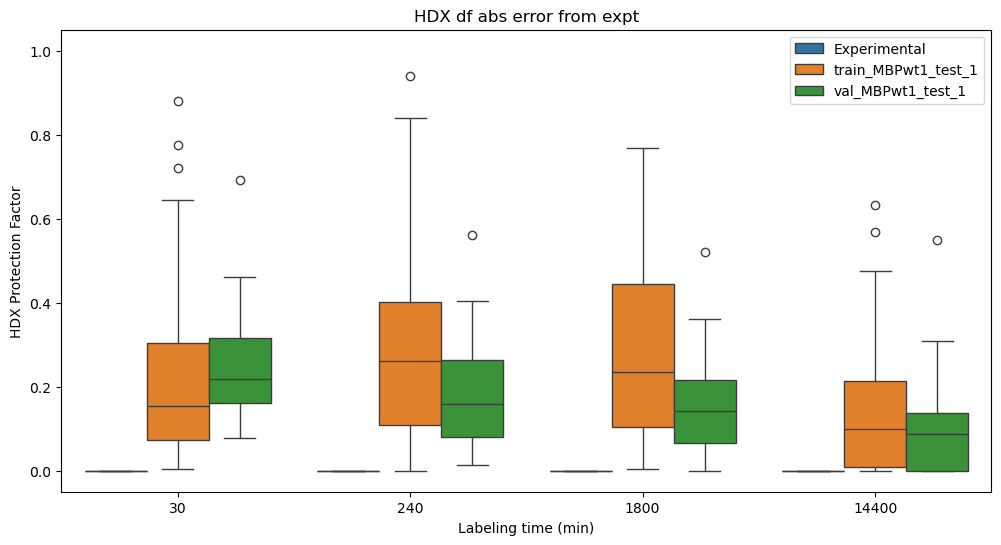

plot_dfracs_compare_MSE
          30      240     1800    14400  peptide            calc_name  ResStr  \
0    0.20624  0.24494  0.37350  0.43061       25  train_MBPwt1_test_1     NaN   
1    0.33854  0.37078  0.47792  0.52550       26  train_MBPwt1_test_1     NaN   
2    0.31004  0.41756  0.55249  0.59329       27  train_MBPwt1_test_1     NaN   
3    0.52834  0.65349  0.80879  0.83979       28  train_MBPwt1_test_1     NaN   
4    1.00000  1.00000  1.00000  1.00000       29  train_MBPwt1_test_1     NaN   
..       ...      ...      ...      ...      ...                  ...     ...   
250  0.38982  0.76948  0.97076  1.00000      106         Experimental     NaN   
251  0.68306  0.87952  0.98129  1.00000      107         Experimental     NaN   
252  0.68912  0.88158  0.97928  1.00000      108         Experimental     NaN   
253  0.59870  0.85358  0.98298  1.00000      109         Experimental     NaN   
254  0.96768  1.00000  0.98548  0.99509      110         Experimental     NaN   

   

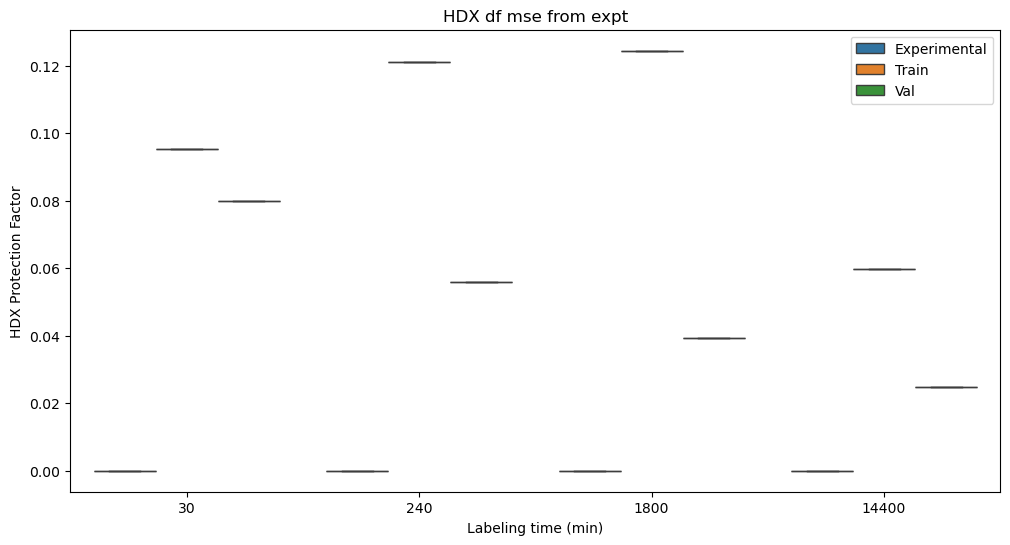

Saving experiment to:  logs/mixAandB_Sp_1708611760.pkl


/home/alexi/Documents/ValDX/ValDX/Experiment_ABC.py:929: UserWarning: Reader has no dt information, set to 1.0 ps
  pickle.dump(self, f)


In [25]:

splits = ['S', 'SR', 'Sp']
split_names = ['AvsB', 'LvsX', 'mixAandB']
system = 'BPTITtut_test'

raw_run_outputs = {}
analysis_dumps = {}
analysis_df = pd.DataFrame()
names = []
save_paths = []


for split, split_name in zip(splits, split_names):
    run_outputs, analysis_dump, df, name, save_path = run_split_test(split, split_name, system)
    raw_run_outputs[name] = run_outputs
    analysis_dumps.update(analysis_dump)
    analysis_df = pd.concat([analysis_df, df])
    names.append(name)
    save_paths.append(save_path)



/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/seaborn/axisgrid.py:723: UserWarning: Using the boxplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)


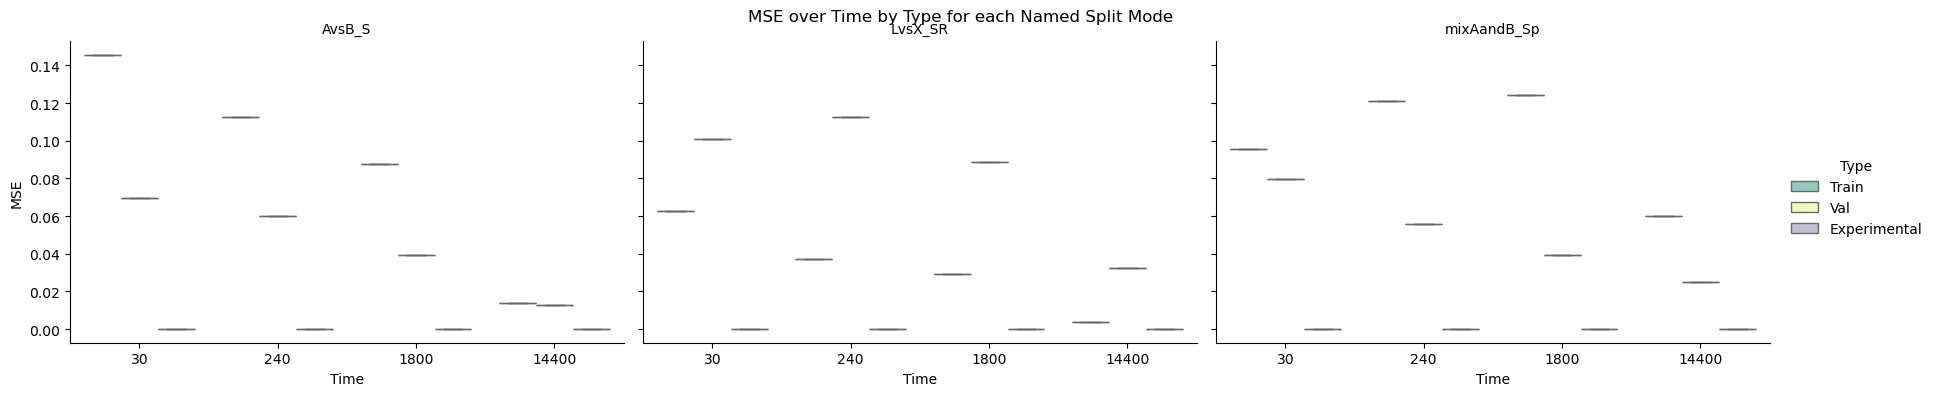

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
# Replace 'your_dataframe' with your actual DataFrame variable
df = analysis_df

# Create a FacetGrid, using 'name' for each subplot
g = sns.FacetGrid(df, col="name", col_wrap=3, height=4, aspect=1.5)
g.fig.suptitle('MSE over Time by Type for each Named Split Mode')

# Create boxplots
g = g.map(sns.boxplot, "time", "mse", "Type", palette="Set3")

# Adding some additional options for better visualization
g.add_legend(title='Type')
g.set_axis_labels("Time", "MSE")
g.set_titles("{col_name}")

# Adjust the arrangement of the plots
plt.subplots_adjust(top=0.9)

# Show plot
plt.show()


/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/seaborn/axisgrid.py:723: UserWarning: Using the boxplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)


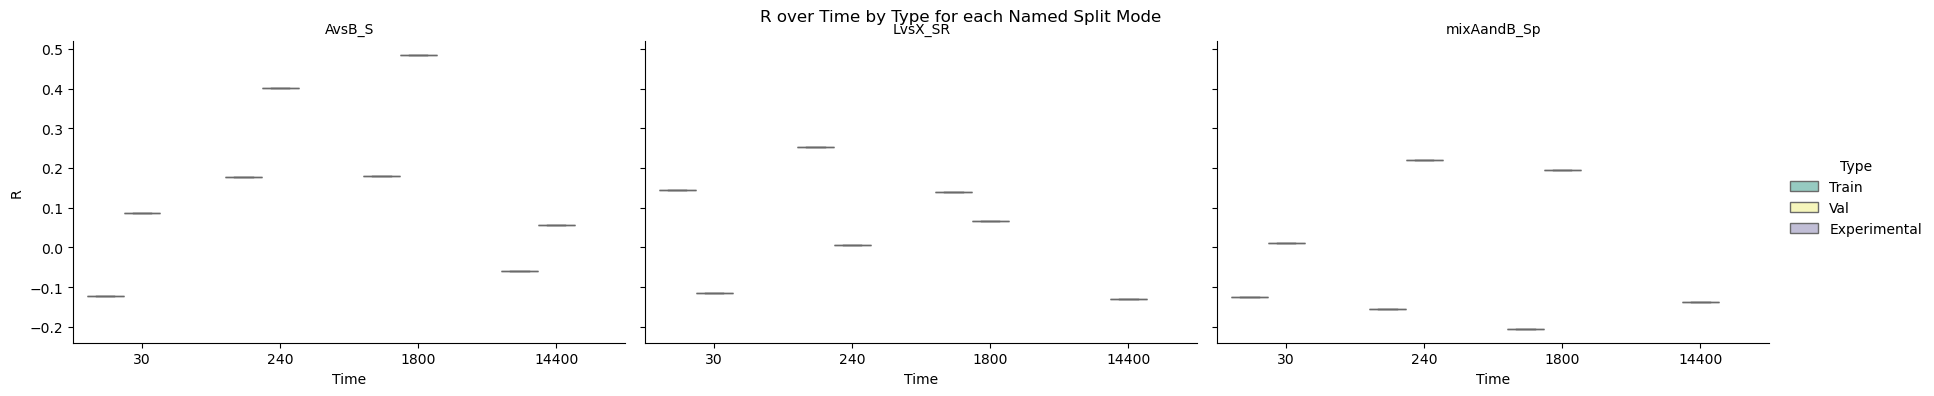

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
# Replace 'your_dataframe' with your actual DataFrame variable
df = analysis_df

# Create a FacetGrid, using 'name' for each subplot
g = sns.FacetGrid(df, col="name", col_wrap=3, height=4, aspect=1.5)
g.fig.suptitle('R over Time by Type for each Named Split Mode')

# Create boxplots
g = g.map(sns.boxplot, "time", "R", "Type", palette="Set3")

# Adding some additional options for better visualization
g.add_legend(title='Type')
g.set_axis_labels("Time", "R")
g.set_titles("{col_name}")

# Adjust the arrangement of the plots
plt.subplots_adjust(top=0.9)

# Show plot
plt.show()


                                               LogPf                calc_name  \
0  [16.643803889682594, 14.902467079579205, 16.20...      train_MBPwt1_test_1   
1  [13.549999999999999, 13.549999999999999, 9.7, ...  no_weight_MBPwt1_test_1   
2  [14.467132877053357, 14.467132877053357, 9.678...        val_MBPwt1_test_1   
3  [14.467132877053357, 14.467132877053357, 9.678...       test_MBPwt1_test_1   
0  [15.633641068475624, 15.633641068475624, 10.46...      train_MBPwt1_test_1   
1  [13.549999999999999, 13.549999999999999, 9.7, ...  no_weight_MBPwt1_test_1   
2  [17.514111263590856, 19.864699007484894, 13.75...        val_MBPwt1_test_1   
3  [15.633641068475624, 15.633641068475624, 10.46...       test_MBPwt1_test_1   
0  [19.181338288960923, 17.168156542292557, 18.67...      train_MBPwt1_test_1   
1  [13.549999999999999, 13.549999999999999, 9.7, ...  no_weight_MBPwt1_test_1   
2  [15.154974795624192, 14.092272226678556, 10.56...        val_MBPwt1_test_1   
3  [16.664861105625466, 16.6

ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

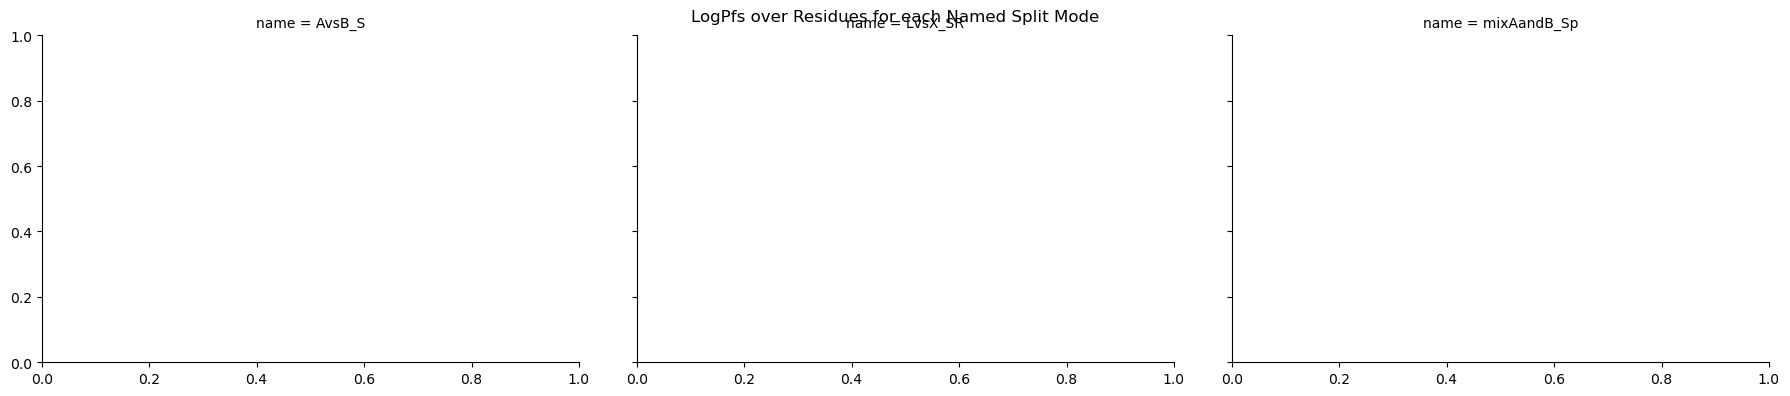

In [29]:
# plot LogPfs by Residues colour by calc_name facet wrap by name
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
LogPfs = pd.concat([analysis_dumps[i]["LogPfs"] for i in names])

print(LogPfs)

LogPfs_df = LogPfs.explode(['LogPf','Residues'])


# Create a FacetGrid, using 'name' for each subplot
g = sns.FacetGrid(LogPfs_df, col="name", col_wrap=3, height=4, aspect=1.5)
g.fig.suptitle('LogPfs over Residues for each Named Split Mode')

# Create lineplots
g = g.map(sns.lineplot, "Residues", "LogPf", "calc_name", palette="Set2")

# Adding some additional options for better visualization
g.add_legend(title='calc_name')
g.set_axis_labels("Residues", "LogPf")
g.set_titles("{col_name}")

# Adjust the arrangement of the plots
plt.subplots_adjust(top=0.9)

# Show plot
plt.show()


In [ ]:
# from MDAnalysis.analysis.dssp import DSSP



In [ ]:
# VDX.paths.head()

In [ ]:
# print(top_path)

In [ ]:
# pdb_test = mda.Universe(top_path)

# # write out as a pdb and add header
# pdb_test.atoms.write('test.pdb')
# with open('test.pdb', 'r') as original: data = original.read()
# with open('test.pdb', 'w') as modified: modified.write('HEADER    '+sim_name+'\n'+data)



In [ ]:


# def PDB_to_DSSP(top_path: str, dssp_path: str=None, sim_name: str=None):
#     """
#     Run DSSP on a PDB file to generate a DSSP file. Reads the output and returns a list of secondary structure elements.
#     Secondary structure elements are reduced to a single character: H (alpha helix), S (beta sheet), or L (loop).
#     Args:
#     - top_path (str): The path to the topology file to create the PDB file from.
#     - dssp_path (str): The path to save the DSSP file.
#     - sim_name (str): Simulation name to be included in the HEADER of the PDB file.
#     Returns:
#     - List of tuples, each containing the residue number and its secondary structure element.
#     """
#     temp_pdb = "do_mkdssp.pdb"

#     if sim_name is None:
#         sim_name = "DSSP HEADER"
#     if dssp_path is None:
#         dssp_path = "dssp_file.dssp"
#     print(top_path)
#     pdb_test = mda.Universe(top_path)

#     # write out as a pdb and add header
#     pdb_test.atoms.write(temp_pdb)


#     with open(temp_pdb, 'r') as original: data = original.read()
#     with open(temp_pdb, 'w') as modified: modified.write('HEADER    '+sim_name+'\n'+data)

#     # Run mkdssp to generate DSSP file
#     try:
#         subprocess.run(['mkdssp', temp_pdb,  dssp_path], check=True)
#     except subprocess.CalledProcessError as e:
#         print(f"Error running DSSP: {e}")
#         return []

#     # Parse the DSSP file
#     secondary_structures = []
#     with open(dssp_path, 'r') as dssp_file:
#         # Skip header lines
#         for line in dssp_file:
#             if line.startswith('  #  RESIDUE AA'):
#                 break
#         # Read the secondary structure assignments
#         for line in dssp_file:
#             if len(line) > 13:  # Ensure line has enough data
#                 residue_num = line[5:10].strip()
#                 ss = line[16]
#                 # Simplify the secondary structure to H, S, or L
#                 if ss in 'GHI':
#                     ss = 'H'  # Helix
#                 elif ss in 'EB':
#                     ss = 'S'  # Sheet
#                 else:
#                     ss = 'L'  # Loop or other
#                 secondary_structures.append((residue_num, ss))

#     # Cleanup temp PDB file
#     os.remove(temp_pdb)
#     os.remove(dssp_path)
#     print(len(secondary_structures))
#     print(len(pdb_test.residues))
#     return secondary_structures

